# Train ROI detector — name / number / collection

The card is already cropped (63×88 mm). This notebook trains **YOLO OBB** on the three text bands: `name`, `number`, `colection`.

It does **not** read the characters. Reading: [`train_ocr.ipynb`](train_ocr.ipynb).

**ocr-roi-v3** é o sweep de arquitetura (no mesmo espírito do detector v6): treina YOLOv26, YOLOv12, YOLOv8 e YOLOv11 com a receita de faixa do v2. O treino gera a **tabela de ranking** de todas as famílias. **Só no fim** elege o melhor e mostra curvas/fotos **desse** vencedor (globais e por classe). RT-DETR fica de fora — não tem OBB oficial, e as faixas são polígonos rotacionados.

Checkpoints oficiais em `src/detection/weights/`. Runs em `src/roi/runs/`.

| Step | Goal |
|---|---|
| 0 | Versão, candidatos, loss e data augmentation |
| 1 | Ambiente (CUDA / Ultralytics) |
| 2 | Dataset `data/roi/` e amostra das faixas |
| 3 | Treino de **cada** família (sem eleger vencedor) |
| 4 | Helper de relatório (sem gráficos ainda) |
| 5 | Eleger o melhor modelo → `ocr-roi-v3.pt` |
| 6 | Gráficos e fotos **só do vencedor** |
| 7 | Predição no test com o vencedor |


`VERSION = "v3"` grava em `src/roi/runs/ocr-roi-v3/<id>/`. A augmentation é a do **ocr-roi-v2** (HSV como o detector de carta, geometria fraca, sem flip/mosaic): a imagem já é a carta reta 63×88 mm.

Cada família parte do checkpoint **oficial** em `src/detection/weights/` (`yolo26s-obb.pt`, …), não do `ocr-roi-v1.pt`. YOLOv12 usa o yaml OBB + `yolo12n.pt`.

Early stop com `patience=40` (teto `epochs=300`): se o val não melhorar, o treino daquela família acaba sozinho — igual ao detector v6.

A pipeline continua em **ocr-roi-v2** até você copiar o vencedor deste sweep.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

VERSION = "v3"
EXPERIMENT_NAME = f"ocr-roi-{VERSION}"


def find_repo() -> Path:
    here = Path(".").resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "cropper" / "rectify.py").is_file() and (p / "src" / "detection").is_dir():
            return p
    raise FileNotFoundError(
        "Open this notebook from the PTCG Scanner repo (folders src/cropper/ and src/detection/)."
    )


REPO = find_repo()
os.chdir(REPO)
ROOT = REPO / "src" / "roi"
DATASET_DIR = REPO / "data" / "roi"
DATA_YAML = DATASET_DIR / "data.yaml"
WEIGHTS_CACHE = REPO / "src" / "detection" / "weights"
RUNS_ROOT = ROOT / "runs"
PROJECT_DIR = RUNS_ROOT
SWEEP_DIR = PROJECT_DIR / EXPERIMENT_NAME
RANKING_CSV = SWEEP_DIR / "ranking.csv"


def bind_run_paths(run_dir: Path) -> None:
    global RUN_DIR, WEIGHTS_DIR
    RUN_DIR = Path(run_dir)
    WEIGHTS_DIR = RUN_DIR / "weights"


def find_existing_run_dir() -> Path | None:
    names = ("best.pt", f"{EXPERIMENT_NAME}.pt", "last.pt")
    candidates = [
        PROJECT_DIR / EXPERIMENT_NAME,
        PROJECT_DIR / "obb" / EXPERIMENT_NAME,
    ]
    for folder in candidates:
        weights = folder / "weights"
        if any((weights / name).exists() for name in names):
            return folder
    if PROJECT_DIR.exists():
        for name in names:
            for pt in PROJECT_DIR.rglob(name):
                if EXPERIMENT_NAME in pt.parts and pt.parent.name == "weights":
                    return pt.parent.parent
    return None


def resolve_pretrained(name: str) -> str:
    raw = Path(name)
    if raw.is_file():
        return str(raw.resolve())
    cached = WEIGHTS_CACHE / raw.name
    if cached.is_file():
        return str(cached)
    return name


def configure_ultralytics_dirs() -> None:
    WEIGHTS_CACHE.mkdir(parents=True, exist_ok=True)
    RUNS_ROOT.mkdir(parents=True, exist_ok=True)
    try:
        from ultralytics.utils import SETTINGS

        SETTINGS.update({"runs_dir": str(RUNS_ROOT), "weights_dir": str(WEIGHTS_CACHE)})
    except Exception as err:
        print(f"[aviso] não deu para fixar SETTINGS do Ultralytics: {err}")


WEIGHTS_CACHE.mkdir(parents=True, exist_ok=True)
bind_run_paths(SWEEP_DIR)
_existing = find_existing_run_dir()
if _existing:
    bind_run_paths(_existing)

EPOCHS = 300
IMGSZ = 800
BATCH = 8
PATIENCE = 40
SEED = 42
WORKERS = 0
CONF = 0.4
MAX_SHOW = 8
SKIP_EXISTING = True
CACHE_IMAGES = True

CANDIDATES = [
    {"id": "yolo26", "family": "YOLOv26", "model": "yolo26s-obb.pt", "imgsz": IMGSZ, "batch": BATCH},
    {
        "id": "yolo12",
        "family": "YOLOv12",
        "model": "yolo12n-obb.yaml",
        "init_from": "yolo12n.pt",
        "imgsz": IMGSZ,
        "batch": BATCH,
    },
    {"id": "yolov8", "family": "YOLOv8", "model": "yolov8s-obb.pt", "imgsz": IMGSZ, "batch": BATCH},
    {"id": "yolo11", "family": "YOLOv11", "model": "yolo11s-obb.pt", "imgsz": IMGSZ, "batch": BATCH},
]

OPTIM = dict(optimizer="AdamW", lr0=0.001, lrf=0.01)
LOSS = dict(box=10.0, dfl=2.0, angle=1.5, cls=0.75)
AUGMENT = dict(
    degrees=10.0,
    flipud=0.0,
    fliplr=0.0,
    translate=0.08,
    scale=0.25,
    shear=1.0,
    perspective=0.0,
    hsv_h=0.02,
    hsv_s=0.70,
    hsv_v=0.50,
    bgr=0.0,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.0,
    close_mosaic=0,
    cos_lr=True,
)
PRETRAINED_MODEL = CANDIDATES[0]["model"]

print(f"Experimento : {EXPERIMENT_NAME}")
print(f"cwd         : {Path.cwd()}")
print(f"Dataset     : {DATASET_DIR}  yaml={DATA_YAML.exists()}")
print(f"Saída       : {SWEEP_DIR}")
print(f"Pesos cache : {WEIGHTS_CACHE}")
print(
    f"Candidatos  : {len(CANDIDATES)}  |  epochs={EPOCHS}  patience={PATIENCE}  "
    f"skip_existing={SKIP_EXISTING}"
)
for cand in CANDIDATES:
    extra = f"  from={cand['init_from']}" if cand.get("init_from") else ""
    print(
        f"  - {cand['family']:12s}  {cand['model']:20s}  "
        f"imgsz={cand['imgsz']}  batch={cand['batch']}{extra}"
    )
print(f"Loss        : box={LOSS['box']} dfl={LOSS['dfl']} angle={LOSS['angle']} cls={LOSS['cls']} | {OPTIM}")
print(
    "Augment     : "
    f"degrees={AUGMENT['degrees']} hsv_h={AUGMENT['hsv_h']} "
    f"hsv_s={AUGMENT['hsv_s']} hsv_v={AUGMENT['hsv_v']} "
    f"scale={AUGMENT['scale']} translate={AUGMENT['translate']} "
    f"flipud={AUGMENT['flipud']} fliplr={AUGMENT['fliplr']} "
    f"mosaic={AUGMENT['mosaic']} mixup={AUGMENT['mixup']} erasing={AUGMENT['erasing']}"
)
print("Checkpoints oficiais:")
_pts = sorted(WEIGHTS_CACHE.glob("*.pt"))
if not _pts:
    print(f"  (vazio — o Ultralytics baixa para {WEIGHTS_CACHE})")
else:
    for _p in _pts:
        print(f"  {_p.name:24s}  {_p.stat().st_size / 1024**2:6.1f} MB")


Experimento : ocr-roi-v3
cwd         : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao
Dataset     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\roi  yaml=True
Saída       : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3
Pesos cache : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\weights
Candidatos  : 4  |  epochs=300  patience=40  skip_existing=True
  - YOLOv26       yolo26s-obb.pt        imgsz=800  batch=8
  - YOLOv12       yolo12n-obb.yaml      imgsz=800  batch=8  from=yolo12n.pt
  - YOLOv8        yolov8s-obb.pt        imgsz=800  batch=8
  - YOLOv11       yolo11s-obb.pt        imgsz=800  batch=8
Loss        : box=10.0 dfl=2.0 angle=1.5 cls=0.75 | {'optimizer': 'AdamW', 'lr0': 0.001, 'lrf': 0.01}
Augment     : degrees=10.0 hsv_h=0.02 hsv_s=0.7 hsv_v=0.5 scale=0.25 translate=0.08 flipud=0.0 fliplr=0.0 mosaic=0.0 mixup=0.0 erasing=0.0
Checkpoints oficiais:
  rtdetr-l.pt                 63.4 MB

## 1. Ambiente

Instala dependências se faltar, verifica CUDA.


In [2]:
import subprocess
import sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "pandas": "pandas",
    "pyyaml": "yaml",
    "matplotlib": "matplotlib",
    "opencv-python": "cv2",
    "pillow": "PIL",
}
missing = []
for pip_name, module_name in REQUIRED.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)
if missing:
    print(f"Instalando: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Dependências de treino ok.")


Dependências de treino ok.


In [3]:
from datetime import datetime
import platform

import pandas as pd
import torch
import ultralytics
from IPython.display import display

cuda_ok = torch.cuda.is_available()
DEVICE = 0 if cuda_ok else "cpu"
env_df = pd.DataFrame(
    [
        ("Data/hora", datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
        ("SO", platform.platform()),
        ("Python", platform.python_version()),
        ("PyTorch", torch.__version__),
        ("Ultralytics", ultralytics.__version__),
        ("CUDA", cuda_ok),
        ("GPU", torch.cuda.get_device_name(0) if cuda_ok else "—"),
        ("Dispositivo", DEVICE),
    ],
    columns=["Item", "Valor"],
)
display(env_df)
if DEVICE == "cpu":
    print("\n[AVISO] Sem CUDA — o treino será lento.")

configure_ultralytics_dirs()
print(f"Pesos e runs: {WEIGHTS_CACHE}  |  {RUNS_ROOT}")


,Item,Valor
0,Data/hora,2026-10-09 10:24:32
1,SO,Windows-11-10.0.26200-SP0
2,Python,3.14.7
3,PyTorch,2.11.0+cu128
4,Ultralytics,8.4.173
5,CUDA,True
6,GPU,NVIDIA GeForce RTX 5060
7,Dispositivo,0


Pesos e runs: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\weights  |  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs


## 2. Dataset e anotações

O Ultralytics espera YAML OBB (`train` / `val`, `names`) e labels `class x1 y1 … x4 y4`. Não renomeie `colection` no YAML — é o nome do Roboflow e o pipeline usa esse id.

`colection` **falta em muitas cartas** (set name só quando está impresso). Isso puxa o mAP médio para baixo sem ser bug de anotação.


In [4]:
import yaml
from collections import Counter

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Unzip the Roboflow YOLOv8 OBB export into {DATASET_DIR} (missing data.yaml)."
    )

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
names = cfg.get("names") or {}
if isinstance(names, list):
    names = dict(enumerate(names))
print("classes:", names)

rows = []
cls_total = Counter()
for split in ("train", "valid", "test"):
    img_dir = DATASET_DIR / split / "images"
    lab_dir = DATASET_DIR / split / "labels"
    images = sorted(p for p in img_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    labels = list(lab_dir.glob("*.txt")) if lab_dir.exists() else []
    counts = Counter()
    empty = 0
    for lp in labels:
        text = lp.read_text(encoding="utf-8").strip()
        if not text:
            empty += 1
            continue
        for line in text.splitlines():
            cid = int(line.split()[0])
            counts[cid] += 1
            cls_total[cid] += 1
    rows.append({
        "split": split,
        "imagens": len(images),
        "labels": len(labels),
        "vazios": empty,
        **{names.get(i, str(i)): counts[i] for i in sorted(names)},
    })
display(pd.DataFrame(rows).set_index("split"))
print("total por classe:", {names.get(k, k): v for k, v in sorted(cls_total.items())})


classes: {0: 'colection', 1: 'name', 2: 'number'}


,imagens,labels,vazios,colection,name,number
split,,,,,,
train,1023,1023,0,605,1023,1023
valid,292,292,0,181,292,292
test,146,146,0,85,146,146


total por classe: {'colection': 871, 'name': 1461, 'number': 1461}


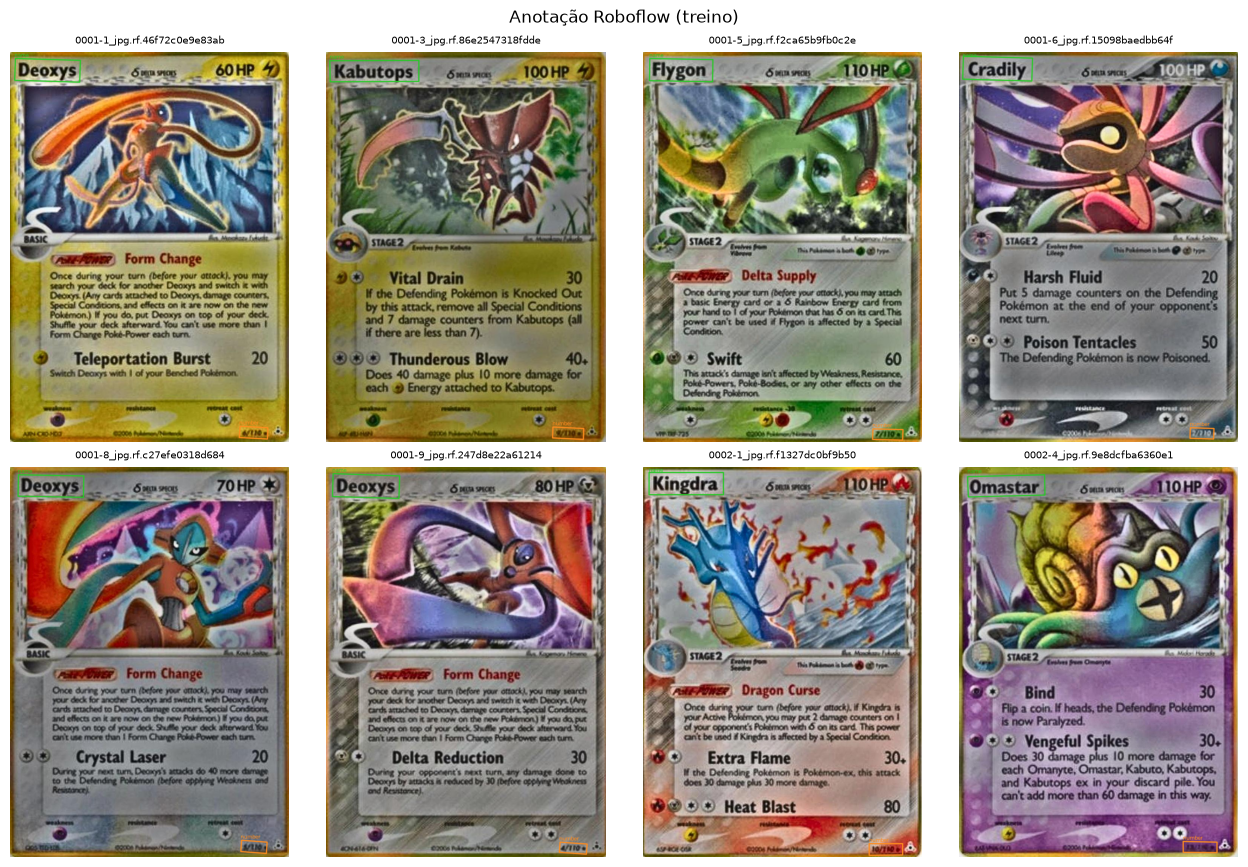

In [5]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import numpy as np

COLORS = {0: (40, 180, 255), 1: (40, 200, 40), 2: (30, 140, 255)}


def draw_obb_label(bgr: np.ndarray, label_path: Path, names: dict) -> np.ndarray:
    vis = bgr.copy()
    h, w = vis.shape[:2]
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return vis
    for line in text.splitlines():
        parts = line.split()
        cid = int(parts[0])
        coords = np.array([float(x) for x in parts[1:]], dtype=np.float32)
        if coords.size == 8:
            pts = coords.reshape(4, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
        else:
            cx, cy, bw, bh = coords[:4]
            x0, y0 = (cx - bw / 2) * w, (cy - bh / 2) * h
            x1, y1 = (cx + bw / 2) * w, (cy + bh / 2) * h
            pts = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=np.float32)
        color = COLORS.get(cid, (200, 200, 200))
        cv2.polylines(vis, [pts.astype(np.int32)], True, color, 2, cv2.LINE_AA)
        x, y = int(pts[:, 0].min()), int(pts[:, 1].min())
        cv2.putText(
            vis,
            names.get(cid, str(cid)),
            (x, max(14, y - 4)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA,
        )
    return vis


train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.jpg"))[:MAX_SHOW]
cols = min(4, max(1, len(train_imgs)))
rows_n = int(np.ceil(len(train_imgs) / cols)) if train_imgs else 1
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, img_path in zip(axes, train_imgs):
    bgr = cv2.imread(str(img_path))
    lab = DATASET_DIR / "train" / "labels" / (img_path.stem + ".txt")
    vis = draw_obb_label(bgr, lab, names) if lab.exists() else bgr
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(train_imgs):]:
    ax.axis("off")
fig.suptitle("Anotação Roboflow (treino)")
plt.tight_layout()
plt.show()


## 3. Treinamento (`ocr-roi-v3` — famílias)

Treina **em sequência** YOLOv26 / 12 / 8 / 11. Mesma augmentation do v2. Sem RT-DETR (não há OBB). Não feche o kernel.

`patience=40` corta épocas inúteis quando o val estagna (teto 300 épocas). Esta célula **não elege** o vencedor — só grava `ranking.csv`. Gráficos e fotos **só do vencedor**: seção 6.

### Data augmentation — o que entra e por quê

O zip do Roboflow **não** traz aug no export. O jitter é **só no treino**. As fotos já são o recorte 63×88 mm.

| Transform | O que faz | Por que neste ROI |
|---|---|---|
| `hsv_h` / `hsv_s` / `hsv_v` | Cor e brilho (mesmos valores do obb-v5) | Glare / PDF vs foto; a tarefa é achar a **faixa** |
| `degrees` (10°) | Rotação leve | Residual do warp; 30° **desalinha** nome vs número |
| `translate` / `scale` | Enquadramento | Cortes um pouco maiores/menores após o cropper |
| `shear` (1°) | Inclinação mínima | Telefone / warp imperfeito |

### O que **não** usamos

| Transform | Motivo |
|---|---|
| `flipud` / `fliplr` | Layout TCG: nome em cima, número embaixo |
| Mosaic / mixup / erasing / perspective | Cortam ou tapam o texto cuja caixa o OCR precisa |

`SKIP_EXISTING=True` pula quem já tem `best.pt`.


In [6]:
import gc
import logging
import os
import sys
import time
from contextlib import contextmanager, redirect_stderr, redirect_stdout

import pandas as pd
import torch
from IPython.display import Markdown, display, update_display
from ultralytics import YOLO

PROGRESS_ID = "roi-sweep-status"
sweep_status = {c["family"]: "esperando" for c in CANDIDATES}
_IPY_STDOUT = sys.stdout
_IPY_STDERR = sys.stderr
os.environ["YOLO_VERBOSE"] = "False"


@contextmanager
def quiet_ultralytics():
    import io
    import ultralytics.utils as uutils
    from ultralytics.utils import LOGGER

    prev_level = LOGGER.level
    prev_verbose = uutils.VERBOSE
    LOGGER.setLevel(logging.ERROR)
    uutils.VERBOSE = False
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            yield
    finally:
        LOGGER.setLevel(prev_level)
        uutils.VERBOSE = prev_verbose


@contextmanager
def cwd(path: Path):
    prev = Path.cwd()
    path.mkdir(parents=True, exist_ok=True)
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(prev)


def render_status() -> None:
    body = "  \n".join(
        f"{cand['family']} - {sweep_status.get(cand['family'], 'esperando')}"
        for cand in CANDIDATES
    )
    old_out, old_err = sys.stdout, sys.stderr
    sys.stdout, sys.stderr = _IPY_STDOUT, _IPY_STDERR
    try:
        update_display(Markdown(body), display_id=PROGRESS_ID)
    finally:
        sys.stdout, sys.stderr = old_out, old_err


def _fmt(v, nd: int = 4) -> str:
    try:
        x = float(v)
    except (TypeError, ValueError):
        return "—"
    if x != x:
        return "—"
    return f"{x:.{nd}f}"


def _attach_epoch_status(model, family: str) -> None:
    def on_train_epoch_end(trainer):
        ep = int(getattr(trainer, "epoch", 0)) + 1
        n = int(getattr(trainer, "epochs", EPOCHS) or EPOCHS)
        sweep_status[family] = f"{ep}/{n} épocas"
        render_status()

    model.add_callback("on_train_epoch_end", on_train_epoch_end)


def _obb_metrics(result) -> dict:
    met = getattr(result, "obb", None) or getattr(result, "box", None)
    p = float(met.mp) if met is not None else float("nan")
    r = float(met.mr) if met is not None else float("nan")
    f1 = 2 * p * r / max(p + r, 1e-9)
    speed = getattr(result, "speed", {}) or {}
    inf_ms = float(speed.get("inference", float("nan")))
    map75 = getattr(met, "map75", None) if met is not None else None
    return {
        "precision": p,
        "recall": r,
        "f1": f1,
        "map50": float(met.map50) if met is not None else float("nan"),
        "map75": float(map75) if map75 is not None else float("nan"),
        "map50_95": float(met.map) if met is not None else float("nan"),
        "infer_ms": inf_ms,
    }


def _is_oom(err: BaseException) -> bool:
    text = f"{type(err).__name__} {err}".lower()
    return "out of memory" in text or ("cuda" in text and "memory" in text)


def _run_finished(cand_dir: Path) -> bool:
    best = cand_dir / "weights" / "best.pt"
    csv_path = cand_dir / "results.csv"
    if not best.is_file() or not csv_path.is_file():
        return False
    hist = pd.read_csv(csv_path)
    if len(hist) >= EPOCHS:
        return True
    map_cols = [c for c in hist.columns if "mAP50-95" in str(c)]
    if not map_cols or len(hist) < PATIENCE + 1:
        return False
    series = hist[map_cols[0]]
    best_i = int(series.idxmax())
    return (len(hist) - 1 - best_i) >= PATIENCE


def _epochs_ran(cand_dir: Path) -> int:
    csv_path = cand_dir / "results.csv"
    if not csv_path.is_file():
        return 0
    try:
        return int(len(pd.read_csv(csv_path)))
    except Exception:
        return 0


def _build_model(cand: dict):
    model_src = resolve_pretrained(cand["model"])
    init_src = resolve_pretrained(cand["init_from"]) if cand.get("init_from") else None
    with cwd(WEIGHTS_CACHE):
        model = YOLO(model_src)
        if init_src:
            try:
                model = model.load(init_src)
            except Exception:
                pass
        return model


def _train_kw(cand: dict, imgsz: int, batch: int) -> dict:
    return dict(
        data=str(DATA_YAML.resolve()),
        epochs=EPOCHS,
        imgsz=imgsz,
        batch=batch,
        device=DEVICE,
        project=str(SWEEP_DIR),
        name=cand["id"],
        exist_ok=True,
        patience=PATIENCE,
        seed=SEED,
        workers=WORKERS,
        pretrained=str(cand["model"]).endswith(".pt"),
        plots=False,
        val=True,
        verbose=False,
        cache=CACHE_IMAGES,
        amp=True,
        save=True,
        **OPTIM,
        **LOSS,
        **AUGMENT,
    )


def train_candidate(cand: dict) -> dict:
    cand_id = cand["id"]
    family = cand["family"]
    cand_dir = SWEEP_DIR / cand_id
    best_pt = cand_dir / "weights" / "best.pt"
    last_pt = cand_dir / "weights" / "last.pt"
    imgsz, batch = int(cand["imgsz"]), int(cand["batch"])
    started = time.time()

    sweep_status[family] = f"0/{EPOCHS} épocas"
    render_status()
    if SKIP_EXISTING and _run_finished(cand_dir):
        pass
    elif last_pt.is_file():
        sweep_status[family] = f"retomando  0/{EPOCHS} épocas"
        render_status()
        with quiet_ultralytics():
            model = YOLO(str(last_pt))
            _attach_epoch_status(model, family)
            model.train(resume=True)
    else:
        while True:
            try:
                model = _build_model(cand)
                _attach_epoch_status(model, family)
                with quiet_ultralytics():
                    model.train(**_train_kw(cand, imgsz, batch))
                break
            except Exception as err:
                if not _is_oom(err):
                    raise
                torch.cuda.empty_cache()
                gc.collect()
                if batch > 1:
                    batch = max(1, batch // 2)
                    sweep_status[family] = f"OOM → batch={batch}"
                    render_status()
                    continue
                if imgsz > 640:
                    imgsz = 640
                    sweep_status[family] = f"OOM → imgsz={imgsz}"
                    render_status()
                    continue
                raise

    if not best_pt.is_file():
        raise FileNotFoundError(f"Sem best.pt em {cand_dir}")

    args_yaml = cand_dir / "args.yaml"
    if args_yaml.is_file():
        import yaml

        saved = yaml.safe_load(args_yaml.read_text(encoding="utf-8")) or {}
        imgsz = int(saved.get("imgsz", imgsz))
        batch = int(saved.get("batch", batch))

    with quiet_ultralytics():
        model = YOLO(str(best_pt))
        val_res = model.val(
            data=str(DATA_YAML.resolve()),
            split="val",
            imgsz=imgsz,
            device=DEVICE,
            project=str(SWEEP_DIR),
            name=f"{cand_id}-val",
            exist_ok=True,
            plots=False,
            workers=WORKERS,
            verbose=False,
        )
    row = {
        "id": cand_id,
        "family": family,
        "model": cand["model"],
        "imgsz": imgsz,
        "batch": batch,
    }
    row.update({f"val_{k}": v for k, v in _obb_metrics(val_res).items()})
    test_imgs = DATASET_DIR / "test" / "images"
    if test_imgs.is_dir() and any(test_imgs.iterdir()):
        with quiet_ultralytics():
            test_res = model.val(
                data=str(DATA_YAML.resolve()),
                split="test",
                imgsz=imgsz,
                device=DEVICE,
                project=str(SWEEP_DIR),
                name=f"{cand_id}-test",
                exist_ok=True,
                plots=False,
                workers=WORKERS,
                verbose=False,
            )
        row.update({f"test_{k}": v for k, v in _obb_metrics(test_res).items()})
    row["hours"] = round((time.time() - started) / 3600, 3)
    row["best_pt"] = str(best_pt)
    n_ep = _epochs_ran(cand_dir)
    row["epochs"] = n_ep
    sweep_status[family] = f"concluído  {n_ep}/{EPOCHS} épocas"
    render_status()
    torch.cuda.empty_cache()
    gc.collect()
    return row


def _ranking_view(ranking: pd.DataFrame) -> pd.DataFrame:
    view = ranking.copy()
    if "best_pt" in view.columns:
        def _short(p):
            if pd.isna(p):
                return p
            path = Path(str(p))
            try:
                return str(path.relative_to(REPO))
            except ValueError:
                return path.name

        view["best_pt"] = view["best_pt"].map(_short)
    num_cols = [c for c in view.columns if c.startswith(("val_", "test_")) or c == "hours"]
    for c in num_cols:
        view[c] = pd.to_numeric(view[c], errors="coerce")
    return view.round(4)


def _show_full_ranking(ranking: pd.DataFrame) -> None:
    """Todas as famílias, val e test sem cortar coluna. Sem gráficos."""
    view = _ranking_view(ranking)
    if "best_pt" in view.columns:
        view = view.drop(columns=["best_pt"])
    meta = [c for c in ("winner", "id", "family", "model", "task", "imgsz", "batch", "epochs", "hours") if c in view.columns]
    val_cols = meta + [c for c in view.columns if str(c).startswith("val_")]
    test_cols = [c for c in ("winner", "id", "family") if c in view.columns] + [
        c for c in view.columns if str(c).startswith("test_")
    ]
    print("Métricas completas — val (todas as famílias)")
    display(view[val_cols])
    print("Métricas completas — test (todas as famílias)")
    display(view[test_cols])


configure_ultralytics_dirs()
os.chdir(REPO)
SWEEP_DIR.mkdir(parents=True, exist_ok=True)

print(f"Sweep {EXPERIMENT_NAME}  |  {len(CANDIDATES)} modelos  |  até {EPOCHS} épocas  |  patience {PATIENCE}")
print(f"Saída: {SWEEP_DIR}")
display(
    Markdown("  \n".join(f"{c['family']} - esperando" for c in CANDIDATES)),
    display_id=PROGRESS_ID,
)

rows = []
for cand in CANDIDATES:
    family = cand["family"]
    try:
        rows.append(train_candidate(cand))
    except Exception as err:
        sweep_status[family] = "falhou"
        render_status()
        print(f"FALHOU {family}: {type(err).__name__}: {err}")
        rows.append(
            {
                "id": cand["id"],
                "family": family,
                "model": cand["model"],
                "imgsz": cand["imgsz"],
                "batch": cand["batch"],
                "error": str(err),
            }
        )
        torch.cuda.empty_cache()
        gc.collect()

ranking = pd.DataFrame(rows)
ranking.to_csv(RANKING_CSV, index=False, encoding="utf-8")
print("\nMétricas de todos os candidatos (a eleição é só na seção 5):")
print(RANKING_CSV)
_show_full_ranking(ranking)
print("\nRanking de todos está na tabela. Gráficos e fotos só do vencedor, na seção 6.")


Sweep ocr-roi-v3  |  4 modelos  |  até 300 épocas  |  patience 40
Saída: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3


YOLOv26 - concluído  80/300 épocas  
YOLOv12 - concluído  257/300 épocas  
YOLOv8 - concluído  123/300 épocas  
YOLOv11 - concluído  159/300 épocas


Métricas de todos os candidatos (a eleição é só na seção 5):
C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3\ranking.csv
Métricas completas — val (todas as famílias)


,id,family,model,imgsz,batch,epochs,hours,val_precision,val_recall,val_f1,val_map50,val_map75,val_map50_95,val_infer_ms
0,yolo26,YOLOv26,yolo26s-obb.pt,800,8,80,0.042,0.9962,0.9988,0.9975,0.9945,0.9894,0.9645,5.0683
1,yolo12,YOLOv12,yolo12n-obb.yaml,800,8,257,0.002,0.9972,0.9989,0.9980,0.9944,0.9873,0.9064,3.4038
2,yolov8,YOLOv8,yolov8s-obb.pt,800,8,123,0.002,0.9974,0.9959,0.9966,0.9939,0.9930,0.9655,4.9142
3,yolo11,YOLOv11,yolo11s-obb.pt,800,8,159,0.002,0.9953,0.9974,0.9964,0.9934,0.9886,0.9625,4.7481


Métricas completas — test (todas as famílias)


,id,family,test_precision,test_recall,test_f1,test_map50,test_map75,test_map50_95,test_infer_ms
0,yolo26,YOLOv26,0.9993,1.0000,0.9996,0.995,0.9910,0.9707,5.0533
1,yolo12,YOLOv12,1.0000,0.9977,0.9989,0.995,0.9800,0.9057,3.5459
2,yolov8,YOLOv8,0.9983,0.9995,0.9989,0.995,0.9909,0.9668,4.9992
3,yolo11,YOLOv11,0.9993,0.9977,0.9985,0.995,0.9877,0.9628,4.7701



Ranking de todos está na tabela. Gráficos e fotos só do vencedor, na seção 6.


## 4. Como as métricas são lidas

A tabela de **todos** os candidatos fica no treino (seção 3) e na eleição (seção 5). Gráficos, fotos e métricas por classe pesadas saem **só na seção 6**, para o vencedor.

Este detector **não** mede CER nem acerto no catálogo.

### Globais (média das 3 classes)

| Métrica | Por que no ROI |
|---|---|
| **Precision** | Faixa extra → EasyOCR lê lixo |
| **Recall** | Faixa perdida → aquele campo some no catálogo |
| **mAP@0.50:0.95** | Critério principal do ranking (como no detector v6) |
| **ms / imagem** | Desempate |

### Por classe

`colection` falta em muitas cartas (set não impresso). AP mais baixo nessa classe **não** significa que o OCR falhou.


In [7]:
from typing import Any

import logging
import numpy as np
import pandas as pd
import torch
from IPython.display import Image as IPyImage, display as ipy_display
from ultralytics import YOLO

CLASS_NAMES = names if isinstance(names, dict) else dict(enumerate(names))

PLOT_SPECS = [
    ("Matriz de confusão (contagens)", "confusion_matrix.png"),
    ("Curva F1 vs Confidence", "BoxF1_curve.png"),
    ("Curva Precision–Recall", "BoxPR_curve.png"),
    ("Curvas de treino (results.png)", "results.png"),
]
PLOT_ALIASES = {
    "BoxF1_curve.png": ["F1_curve.png"],
    "BoxPR_curve.png": ["PR_curve.png"],
}


def _to_float(value: Any) -> float | None:
    if value is None:
        return None
    if isinstance(value, (float, int)):
        return float(value)
    try:
        arr = np.asarray(value, dtype=float)
        if arr.size == 0:
            return None
        return float(arr.mean()) if arr.ndim else float(arr)
    except (TypeError, ValueError):
        return None


def _to_list(value: Any) -> list[float]:
    if value is None:
        return []
    if torch.is_tensor(value):
        value = value.detach().cpu().numpy()
    return [float(x) for x in np.asarray(value, dtype=float).reshape(-1)]


def get_obb_namespace(metrics_obj) -> tuple[Any, str]:
    if hasattr(metrics_obj, "obb") and metrics_obj.obb is not None:
        ns = metrics_obj.obb
        if _to_float(getattr(ns, "map", None)) is not None:
            return ns, "obb"
    if hasattr(metrics_obj, "box") and metrics_obj.box is not None:
        return metrics_obj.box, "box"
    raise AttributeError("Sem metrics.obb / metrics.box.")


def extract_speed_ms(metrics_obj) -> float | None:
    speed = getattr(metrics_obj, "speed", None)
    if not isinstance(speed, dict):
        return None
    total = 0.0
    n = 0
    for key in ("preprocess", "inference", "postprocess"):
        val = speed.get(key)
        if val is None:
            continue
        total += float(val)
        n += 1
    return total if n else None


def extract_class_counts(metrics_obj, n_names: int) -> list[dict[str, int | None]]:
    cm_obj = getattr(metrics_obj, "confusion_matrix", None)
    matrix = getattr(cm_obj, "matrix", None) if cm_obj is not None else None
    if matrix is None:
        return [{"TP": None, "FP": None, "FN": None} for _ in range(n_names)]
    m = np.asarray(matrix, dtype=float)
    if m.ndim != 2 or m.shape[0] < n_names:
        return [{"TP": None, "FP": None, "FN": None} for _ in range(n_names)]
    rows = []
    for i in range(n_names):
        tp = int(round(m[i, i]))
        fp = int(round(m[i, :].sum() - m[i, i]))
        fn = int(round(m[:, i].sum() - m[i, i]))
        rows.append({"TP": tp, "FP": fp, "FN": fn})
    return rows


def extract_global(metrics_obj) -> pd.DataFrame:
    ns, source = get_obb_namespace(metrics_obj)
    print(f"Namespace: metrics.{source}")
    p = _to_float(getattr(ns, "mp", None))
    r = _to_float(getattr(ns, "mr", None))
    f1 = None
    if p is not None and r is not None and (p + r) > 0:
        f1 = 2.0 * p * r / (p + r)
    return pd.DataFrame(
        [
            {"Métrica": "Precision (média 3 classes)", "Valor": p, "Por que": "Faixa extra → OCR em arte/HP"},
            {"Métrica": "Recall (média 3 classes)", "Valor": r, "Por que": "Faixa perdida → campo some no catálogo"},
            {"Métrica": "F1", "Valor": f1, "Por que": "P e R; conf da app nas faixas = 0,4"},
            {"Métrica": "mAP@0.50", "Valor": _to_float(getattr(ns, "map50", None)), "Por que": "Achou a faixa?"},
            {"Métrica": "mAP@0.75", "Valor": _to_float(getattr(ns, "map75", None)), "Por que": "Caixa justa para recortar o texto"},
            {"Métrica": "mAP@0.50:0.95", "Valor": _to_float(getattr(ns, "map", None)), "Por que": "COCO: detecção + borda da faixa"},
            {"Métrica": "Tempo (ms/img)", "Valor": extract_speed_ms(metrics_obj), "Por que": "Custo por carta já recortada"},
        ]
    )


def extract_per_class(metrics_obj) -> pd.DataFrame:
    ns, _ = get_obb_namespace(metrics_obj)
    p = _to_list(getattr(ns, "p", None))
    r = _to_list(getattr(ns, "r", None))
    ap50 = _to_list(getattr(ns, "ap50", None))
    ap = _to_list(getattr(ns, "ap", None))
    maps = _to_list(getattr(ns, "maps", None))
    n = max(len(CLASS_NAMES), len(p), len(r), len(ap50), 1)
    counts = extract_class_counts(metrics_obj, n)
    why = {
        "name": "FN = sem nome no catálogo",
        "number": "Confusão típica com colection no rodapé",
        "colection": "Muitas cartas sem set impresso — AP baixo pode ser o dataset",
    }
    rows = []
    for i in range(n):
        cls = CLASS_NAMES.get(i, str(i))
        pi = p[i] if i < len(p) else None
        ri = r[i] if i < len(r) else None
        f1 = None
        if pi is not None and ri is not None and (pi + ri) > 0:
            f1 = 2.0 * pi * ri / (pi + ri)
        ap_val = ap[i] if i < len(ap) else (maps[i] if i < len(maps) else None)
        c = counts[i] if i < len(counts) else {"TP": None, "FP": None, "FN": None}
        rows.append(
            {
                "Classe": cls,
                "Precision": pi,
                "Recall": ri,
                "F1": f1,
                "AP50": ap50[i] if i < len(ap50) else None,
                "AP50-95": ap_val,
                "TP": c["TP"],
                "FP": c["FP"],
                "FN": c["FN"],
                "Por que": why.get(cls, "Faixa desta classe"),
            }
        )
    return pd.DataFrame(rows)


def extract_val_losses(run_dir: Path) -> pd.DataFrame:
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        return pd.DataFrame(columns=["Perda", "Valor", "Papel"])
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]
    wanted = [
        ("Box Loss", ["val/box_loss", "metrics/box_loss"], "Geometria da faixa"),
        ("DFL Loss", ["val/dfl_loss", "metrics/dfl_loss"], "Refino da borda da faixa"),
        ("Angle Loss", ["val/angle_loss", "metrics/angle_loss", "train/angle_loss"], "Inclinação da OBB"),
        ("Class Loss", ["val/cls_loss", "metrics/cls_loss"], "Separar name / number / colection"),
    ]
    rows = []
    for label, candidates, role in wanted:
        col = next((c for c in candidates if c in df.columns), None)
        value = float(last[col]) if col is not None else None
        rows.append({"Perda": label, "Valor": value, "Papel": role})
    return pd.DataFrame(rows)


def _fmt(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    int_cols = {"TP", "FP", "FN"}

    def _round(col, x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return None
        if col in int_cols:
            return int(round(float(x)))
        if col in ("Por que", "Classe", "Métrica", "Perda", "Papel"):
            return x
        try:
            return round(float(x), 4)
        except (TypeError, ValueError):
            return x

    for col in out.columns:
        out[col] = [_round(col, v) for v in out[col]]
    return out


def _find_plot(folders: list[Path], filename: str) -> Path | None:
    names = [filename, *PLOT_ALIASES.get(filename, [])]
    for folder in folders:
        if not folder.is_dir():
            continue
        for name in names:
            direct = folder / name
            if direct.is_file():
                return direct
        for name in names:
            matches = sorted(folder.rglob(name))
            if matches:
                return matches[0]
    return None


def _show_plots(cand_dir: Path, report_dir: Path) -> None:
    folders = [report_dir, cand_dir]
    for title, filename in PLOT_SPECS:
        path = _find_plot(folders, filename)
        if path is None:
            print(f"[ausente] {filename}")
            continue
        print(f"{title}  →  {path}")
        ipy_display(IPyImage(filename=str(path), width=720))
    val_images: list[Path] = []
    for folder in folders:
        if folder.is_dir():
            val_images.extend(sorted(folder.glob("val_batch*_labels.jpg")))
            val_images.extend(sorted(folder.glob("val_batch*_pred.jpg")))
    seen: set[str] = set()
    uniq: list[Path] = []
    for path in val_images:
        if path.name in seen:
            continue
        seen.add(path.name)
        uniq.append(path)
    print("\nLotes de validação (labels vs predições)")
    if not uniq:
        print("Nenhum lote de validação encontrado.")
        return
    for path in uniq:
        print(path.name)
        ipy_display(IPyImage(filename=str(path), width=720))


def _val_quiet(weights: Path, split: str, imgsz: int, plots: bool, project: Path, name: str):
    import io
    from contextlib import redirect_stderr, redirect_stdout
    import ultralytics.utils as uutils
    from ultralytics.utils import LOGGER

    model = YOLO(str(weights))
    prev_level = LOGGER.level
    prev_verbose = uutils.VERBOSE
    LOGGER.setLevel(logging.ERROR)
    uutils.VERBOSE = False
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            return model.val(
                data=str(DATA_YAML.resolve()),
                split=split,
                imgsz=imgsz,
                batch=BATCH,
                workers=WORKERS,
                device=DEVICE,
                plots=plots,
                project=str(project),
                name=name,
                exist_ok=True,
                verbose=False,
            )
    finally:
        LOGGER.setLevel(prev_level)
        uutils.VERBOSE = prev_verbose


def report_candidate(cand_id: str, *, plots: bool = True) -> None:
    cand = next((c for c in CANDIDATES if c["id"] == cand_id), None)
    if cand is None:
        raise KeyError(cand_id)
    cand_dir = SWEEP_DIR / cand_id
    best_pt = cand_dir / "weights" / "best.pt"
    if not best_pt.is_file():
        raise FileNotFoundError(f"Sem best.pt em {cand_dir}. Rode o treino desta família.")
    args_yaml = cand_dir / "args.yaml"
    imgsz = int(cand["imgsz"])
    if args_yaml.is_file():
        import yaml

        saved = yaml.safe_load(args_yaml.read_text(encoding="utf-8")) or {}
        imgsz = int(saved.get("imgsz", imgsz))
    report_dir = cand_dir / "report"

    if RANKING_CSV.is_file():
        rank = pd.read_csv(RANKING_CSV)
        row = rank[rank["id"].astype(str) == cand_id]
        if len(row):
            print("Linha do ranking (treino):")
            display(row.drop(columns=[c for c in ("winner", "best_pt") if c in row.columns], errors="ignore"))

    print(f"\nValidando {cand['family']} ...")
    metrics = _val_quiet(best_pt, "val", imgsz, True, cand_dir, "report")
    print("=" * 72)
    print(f"ROI globais — val — {cand['family']}")
    print("=" * 72)
    display(_fmt(extract_global(metrics)))
    print("Por classe")
    display(_fmt(extract_per_class(metrics)))

    test_imgs = DATASET_DIR / "test" / "images"
    if test_imgs.is_dir() and any(test_imgs.iterdir()):
        metrics_test = _val_quiet(best_pt, "test", imgsz, False, cand_dir, "report-test")
        print("=" * 72)
        print(f"ROI globais — test — {cand['family']}")
        print("=" * 72)
        display(_fmt(extract_global(metrics_test)))
        print("Por classe")
        display(_fmt(extract_per_class(metrics_test)))

    print("\nPerdas da última época (diagnóstico)")
    loss_df = extract_val_losses(cand_dir)
    loss_df["Valor"] = loss_df["Valor"].map(lambda x: None if x is None else round(x, 4))
    display(loss_df)
    print()
    if plots:
        _show_plots(cand_dir, report_dir)
    else:
        print("(sem gráficos — curvas só do vencedor na seção 6)")


print("Helper de relatório ROI pronto. Depois da eleição, a seção 6 mostra só o vencedor.")


Helper de relatório ROI pronto. Depois da eleição, a seção 6 mostra só o vencedor.


## 5. Eleger o melhor modelo

Mesma regra do detector v6: melhor **mAP@0.50:0.95** no val; empate (≤ 0,002) vai para o mais rápido. O peso vira `ocr-roi-v3.pt`.

A pipeline **continua em ocr-roi-v2** até você copiar este arquivo.


In [8]:
import shutil

MAP_TOL = 0.002


def _fmt(v, nd: int = 4) -> str:
    try:
        x = float(v)
    except (TypeError, ValueError):
        return "—"
    if x != x:
        return "—"
    return f"{x:.{nd}f}"


def pick_winner(ok: pd.DataFrame) -> pd.Series:
    best_map = float(ok["val_map50_95"].max())
    near = ok[ok["val_map50_95"] >= best_map - MAP_TOL].copy()
    if "val_infer_ms" in near.columns and near["val_infer_ms"].notna().any():
        near = near.sort_values(["val_infer_ms", "val_map50_95"], ascending=[True, False])
    else:
        near = near.sort_values("val_map50_95", ascending=False)
    return near.iloc[0]


def _ranking_view(ranking: pd.DataFrame) -> pd.DataFrame:
    view = ranking.copy()
    if "best_pt" in view.columns:
        def _short(p):
            if pd.isna(p):
                return p
            path = Path(str(p))
            try:
                return str(path.relative_to(REPO))
            except ValueError:
                return path.name

        view["best_pt"] = view["best_pt"].map(_short)
    num_cols = [c for c in view.columns if c.startswith(("val_", "test_")) or c == "hours"]
    for c in num_cols:
        view[c] = pd.to_numeric(view[c], errors="coerce")
    return view.round(4)


def _show_full_ranking(ranking: pd.DataFrame) -> None:
    """Todas as famílias, val e test sem cortar coluna. Sem gráficos."""
    view = _ranking_view(ranking)
    if "best_pt" in view.columns:
        view = view.drop(columns=["best_pt"])
    meta = [c for c in ("winner", "id", "family", "model", "task", "imgsz", "batch", "epochs", "hours") if c in view.columns]
    val_cols = meta + [c for c in view.columns if str(c).startswith("val_")]
    test_cols = [c for c in ("winner", "id", "family") if c in view.columns] + [
        c for c in view.columns if str(c).startswith("test_")
    ]
    print("Métricas completas — val (todas as famílias)")
    display(view[val_cols])
    print("Métricas completas — test (todas as famílias)")
    display(view[test_cols])


if not RANKING_CSV.is_file():
    raise FileNotFoundError(f"Rode o treino. Faltando {RANKING_CSV}")

ranking = pd.read_csv(RANKING_CSV)
if "winner" in ranking.columns:
    ranking = ranking.drop(columns=["winner"])
ok_rank = ranking.dropna(subset=["val_map50_95"]) if "val_map50_95" in ranking.columns else ranking.iloc[0:0]
if ok_rank.empty:
    display(_ranking_view(ranking))
    raise RuntimeError("Nenhum candidato treinou com sucesso.")

winner = pick_winner(ok_rank)
ranking.insert(0, "winner", ranking["id"].eq(winner["id"]).map({True: "←", False: ""}))
ranking = ranking.sort_values(
    by=[c for c in ("winner", "val_map50_95") if c in ranking.columns],
    ascending=[False, False][: len([c for c in ("winner", "val_map50_95") if c in ranking.columns])],
    na_position="last",
).reset_index(drop=True)
ranking.to_csv(RANKING_CSV, index=False, encoding="utf-8")

print("Ranking final (← = vencedor):")
_show_full_ranking(ranking)

WINNER_ID = str(winner["id"])
IMGSZ = int(winner["imgsz"])
BATCH = int(winner.get("batch") or BATCH)
winner_src = Path(str(winner["best_pt"]))
bind_run_paths(SWEEP_DIR)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(winner_src, WEIGHTS_DIR / "best.pt")
named = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
if named.exists():
    named.unlink()
shutil.copy2(WEIGHTS_DIR / "best.pt", named)
last_src = winner_src.with_name("last.pt")
if last_src.is_file():
    shutil.copy2(last_src, WEIGHTS_DIR / "last.pt")
WEIGHTS = named

print()
print(f"Vencedor: {winner.get('family')}  ({WINNER_ID})")
print(f"  val  mAP50-95={_fmt(winner.get('val_map50_95'))}  F1={_fmt(winner.get('val_f1'), 3)}")
if "test_map50_95" in winner.index and pd.notna(winner.get("test_map50_95")):
    print(f"  test mAP50-95={_fmt(winner.get('test_map50_95'))}")
print(f"  pesos: {WEIGHTS}")
print("A pipeline segue em ocr-roi-v2 até você copiar este arquivo.")


Ranking final (← = vencedor):
Métricas completas — val (todas as famílias)


,winner,id,family,model,imgsz,batch,epochs,hours,val_precision,val_recall,val_f1,val_map50,val_map75,val_map50_95,val_infer_ms
0,←,yolov8,YOLOv8,yolov8s-obb.pt,800,8,123,0.002,0.9974,0.9959,0.9966,0.9939,0.9930,0.9655,4.9142
1,,yolo26,YOLOv26,yolo26s-obb.pt,800,8,80,0.042,0.9962,0.9988,0.9975,0.9945,0.9894,0.9645,5.0683
2,,yolo11,YOLOv11,yolo11s-obb.pt,800,8,159,0.002,0.9953,0.9974,0.9964,0.9934,0.9886,0.9625,4.7481
3,,yolo12,YOLOv12,yolo12n-obb.yaml,800,8,257,0.002,0.9972,0.9989,0.9980,0.9944,0.9873,0.9064,3.4038


Métricas completas — test (todas as famílias)


,winner,id,family,test_precision,test_recall,test_f1,test_map50,test_map75,test_map50_95,test_infer_ms
0,←,yolov8,YOLOv8,0.9983,0.9995,0.9989,0.995,0.9909,0.9668,4.9992
1,,yolo26,YOLOv26,0.9993,1.0000,0.9996,0.995,0.9910,0.9707,5.0533
2,,yolo11,YOLOv11,0.9993,0.9977,0.9985,0.995,0.9877,0.9628,4.7701
3,,yolo12,YOLOv12,1.0000,0.9977,0.9989,0.995,0.9800,0.9057,3.5459



Vencedor: YOLOv8  (yolov8)
  val  mAP50-95=0.9655  F1=0.997
  test mAP50-95=0.9668
  pesos: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3\weights\ocr-roi-v3.pt
A pipeline segue em ocr-roi-v2 até você copiar este arquivo.


## 5b. Métricas completas (todas as famílias)

O pandas cortava colunas (`…`) na tabela única. Aqui val e test aparecem inteiros. **Gráficos e fotos só na seção 6**, do vencedor.

### Val — todas as famílias

| winner | family | model | epochs | val_precision | val_recall | val_f1 | val_map50 | val_map75 | val_map50_95 | val_infer_ms |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ← | YOLOv26 | yolo26s-obb.pt | 80 | 0.9962 | 0.9988 | 0.9975 | 0.9945 | 0.9894 | 0.9645 | 4.8704 |
| — | YOLOv8 | yolov8s-obb.pt | 123 | 0.9974 | 0.9959 | 0.9966 | 0.9939 | 0.9930 | 0.9655 | 4.8727 |
| — | YOLOv11 | yolo11s-obb.pt | 159 | 0.9953 | 0.9974 | 0.9964 | 0.9934 | 0.9886 | 0.9625 | 4.7110 |
| — | YOLOv12 | yolo12n-obb.yaml | 257 | 0.9972 | 0.9989 | 0.9980 | 0.9944 | 0.9873 | 0.9064 | 3.4657 |

### Test — todas as famílias

| winner | family | test_precision | test_recall | test_f1 | test_map50 | test_map75 | test_map50_95 | test_infer_ms |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ← | YOLOv26 | 0.9993 | 1.0000 | 0.9996 | 0.9950 | 0.9910 | 0.9707 | 5.0288 |
| — | YOLOv8 | 0.9983 | 0.9995 | 0.9989 | 0.9950 | 0.9909 | 0.9668 | 4.9195 |
| — | YOLOv11 | 0.9993 | 0.9977 | 0.9985 | 0.9950 | 0.9877 | 0.9628 | 4.7216 |
| — | YOLOv12 | 1.0000 | 0.9977 | 0.9989 | 0.9950 | 0.9800 | 0.9057 | 3.6235 |


## 6. Gráficos e fotos do vencedor

Só o modelo escolhido na seção 5 (`WINNER_ID`). Aqui: **YOLOv26**. Globais e por classe (`name` / `number` / `colection`). O ranking das outras famílias continua na tabela.


Linha do ranking (treino):


,id,family,model,imgsz,batch,val_precision,val_recall,val_f1,val_map50,val_map75,...,val_infer_ms,test_precision,test_recall,test_f1,test_map50,test_map75,test_map50_95,test_infer_ms,hours,epochs
0,yolov8,YOLOv8,yolov8s-obb.pt,800,8,0.997359,0.995894,0.996626,0.993877,0.993038,...,4.914195,0.998297,0.99955,0.998923,0.995,0.990882,0.966838,4.999202,0.002,123



Validando YOLOv8 ...
ROI globais — val — YOLOv8
Namespace: metrics.box


'—'

Por classe


...

Por classe


'—'


Perdas da última época (diagnóstico)


,Perda,Valor,Papel
0,Box Loss,0.3955,Geometria da faixa
1,DFL Loss,1.1389,Refino da borda da faixa
2,Angle Loss,0.0013,Inclinação da OBB
3,Class Loss,0.2338,Separar name / number / colection



Matriz de confusão (contagens)  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3\yolov8\report\confusion_matrix.png


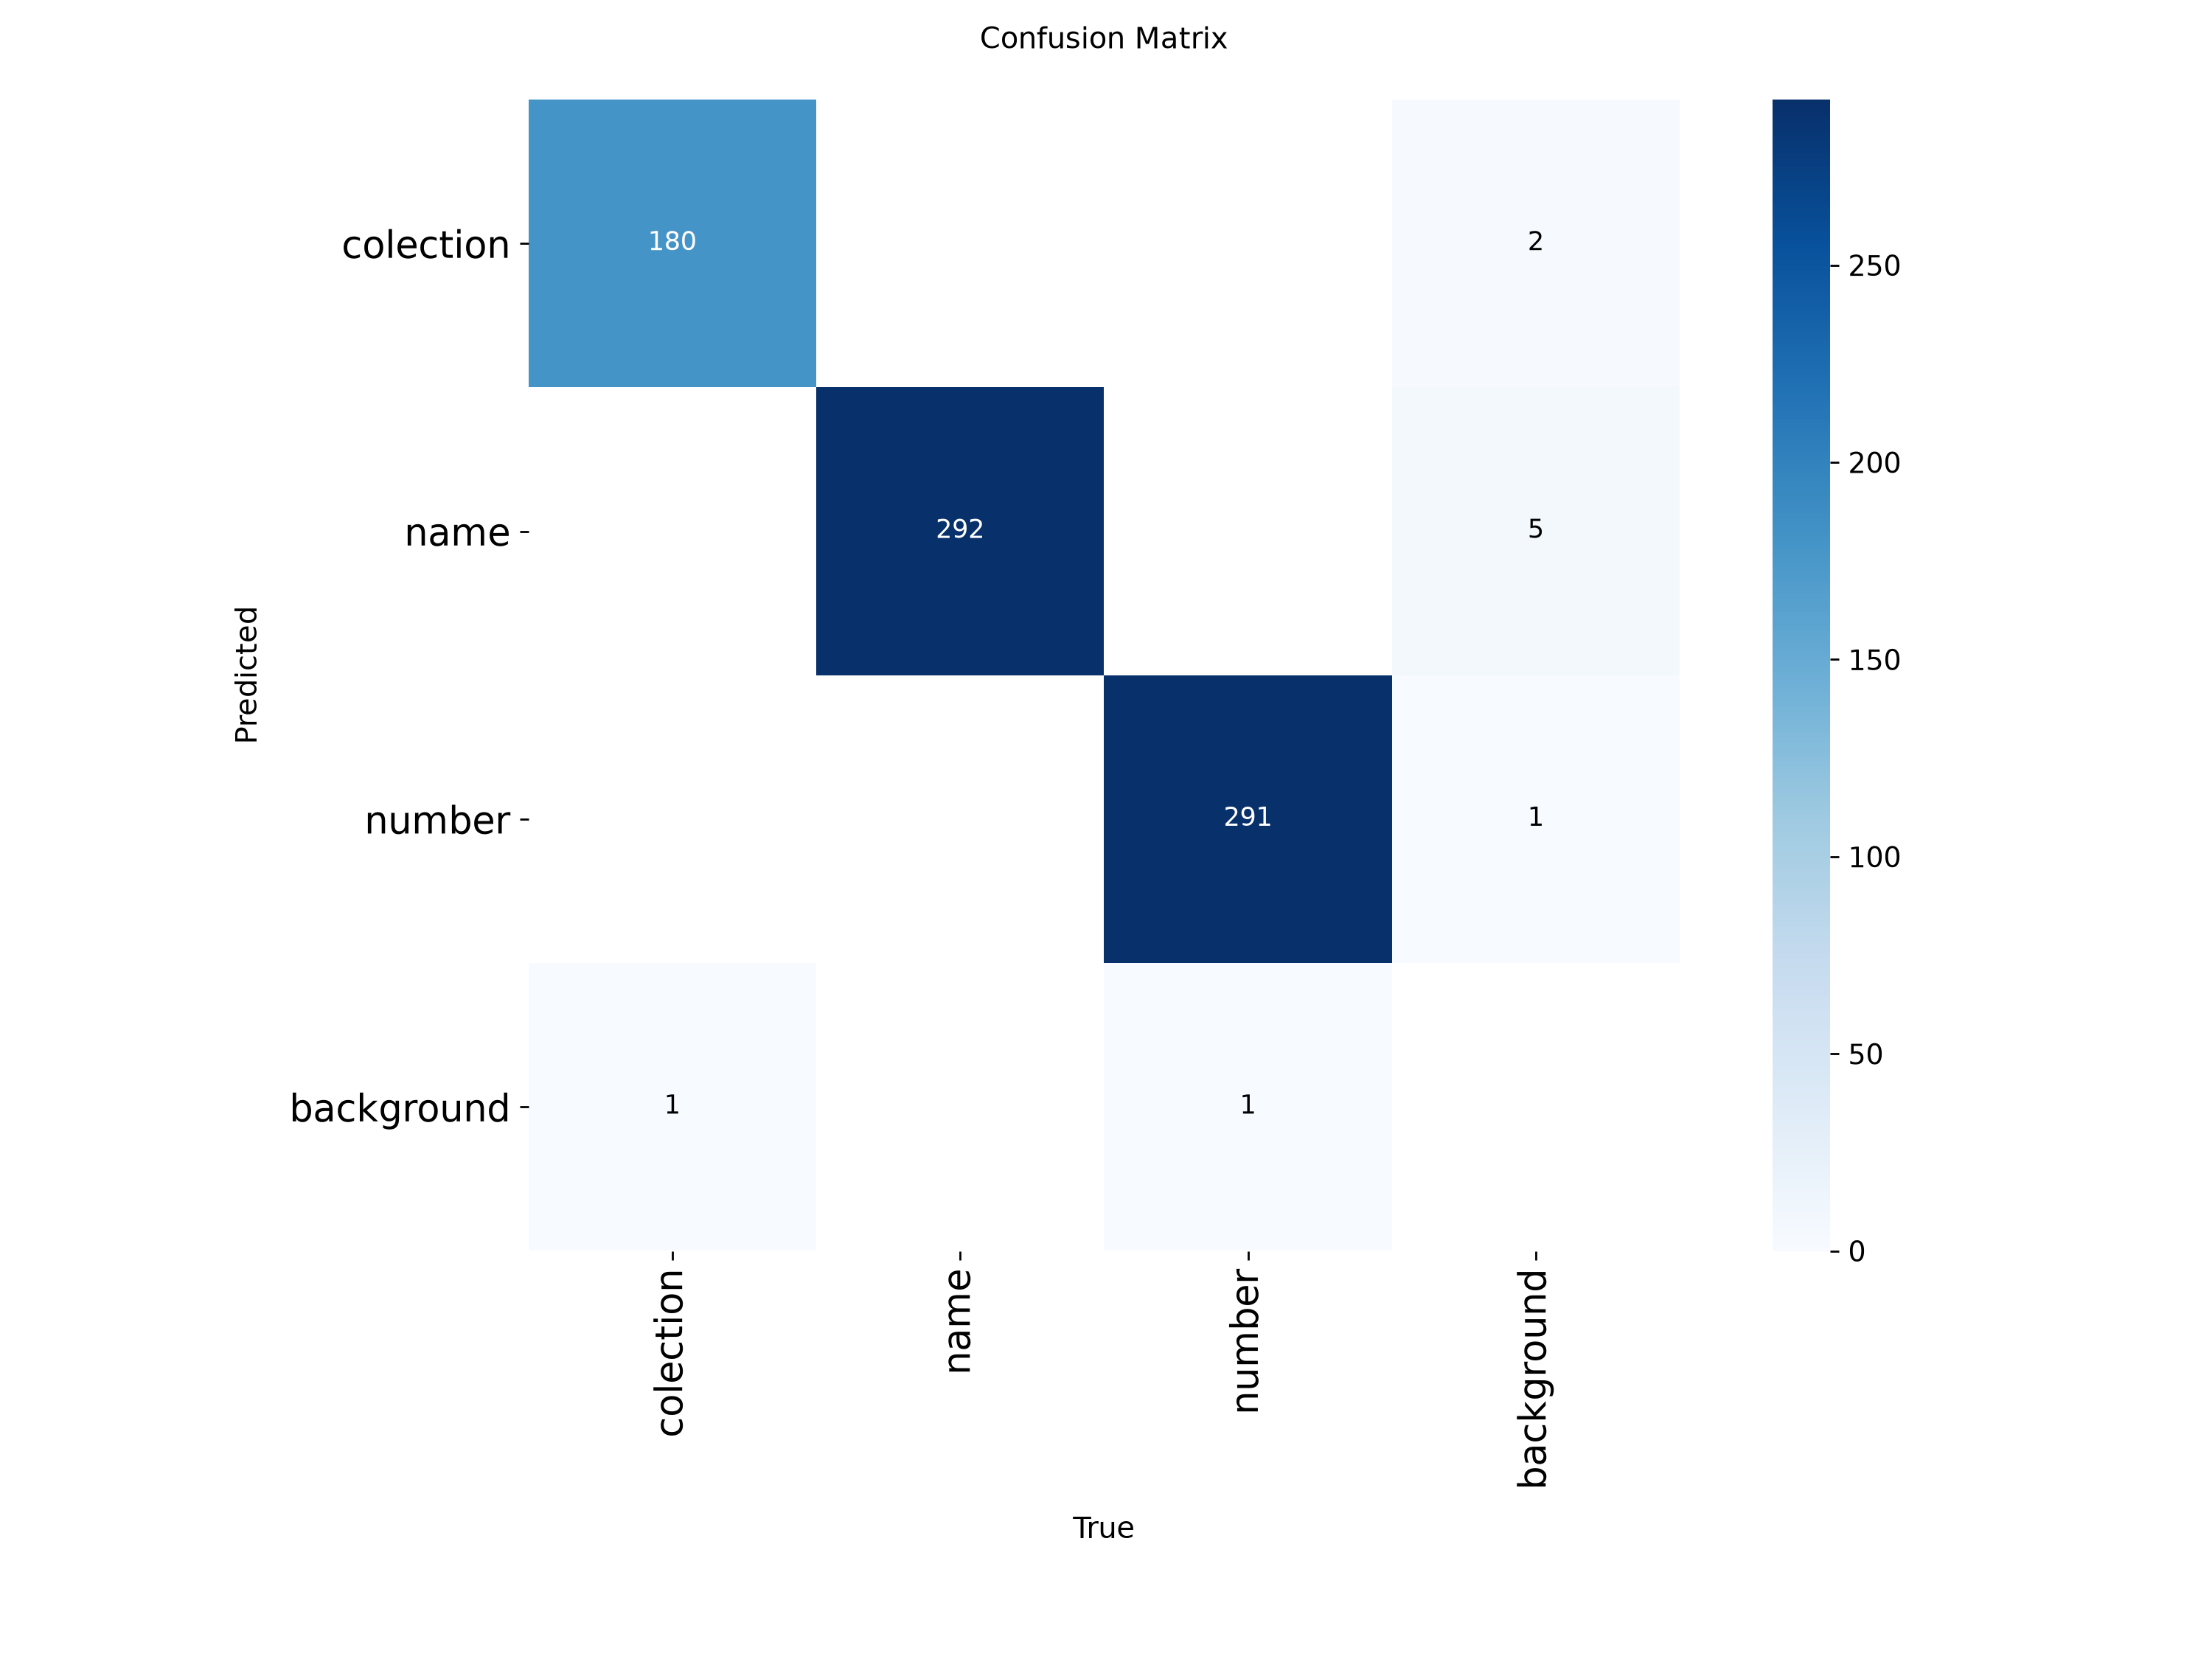

Curva F1 vs Confidence  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3\yolov8\report\BoxF1_curve.png


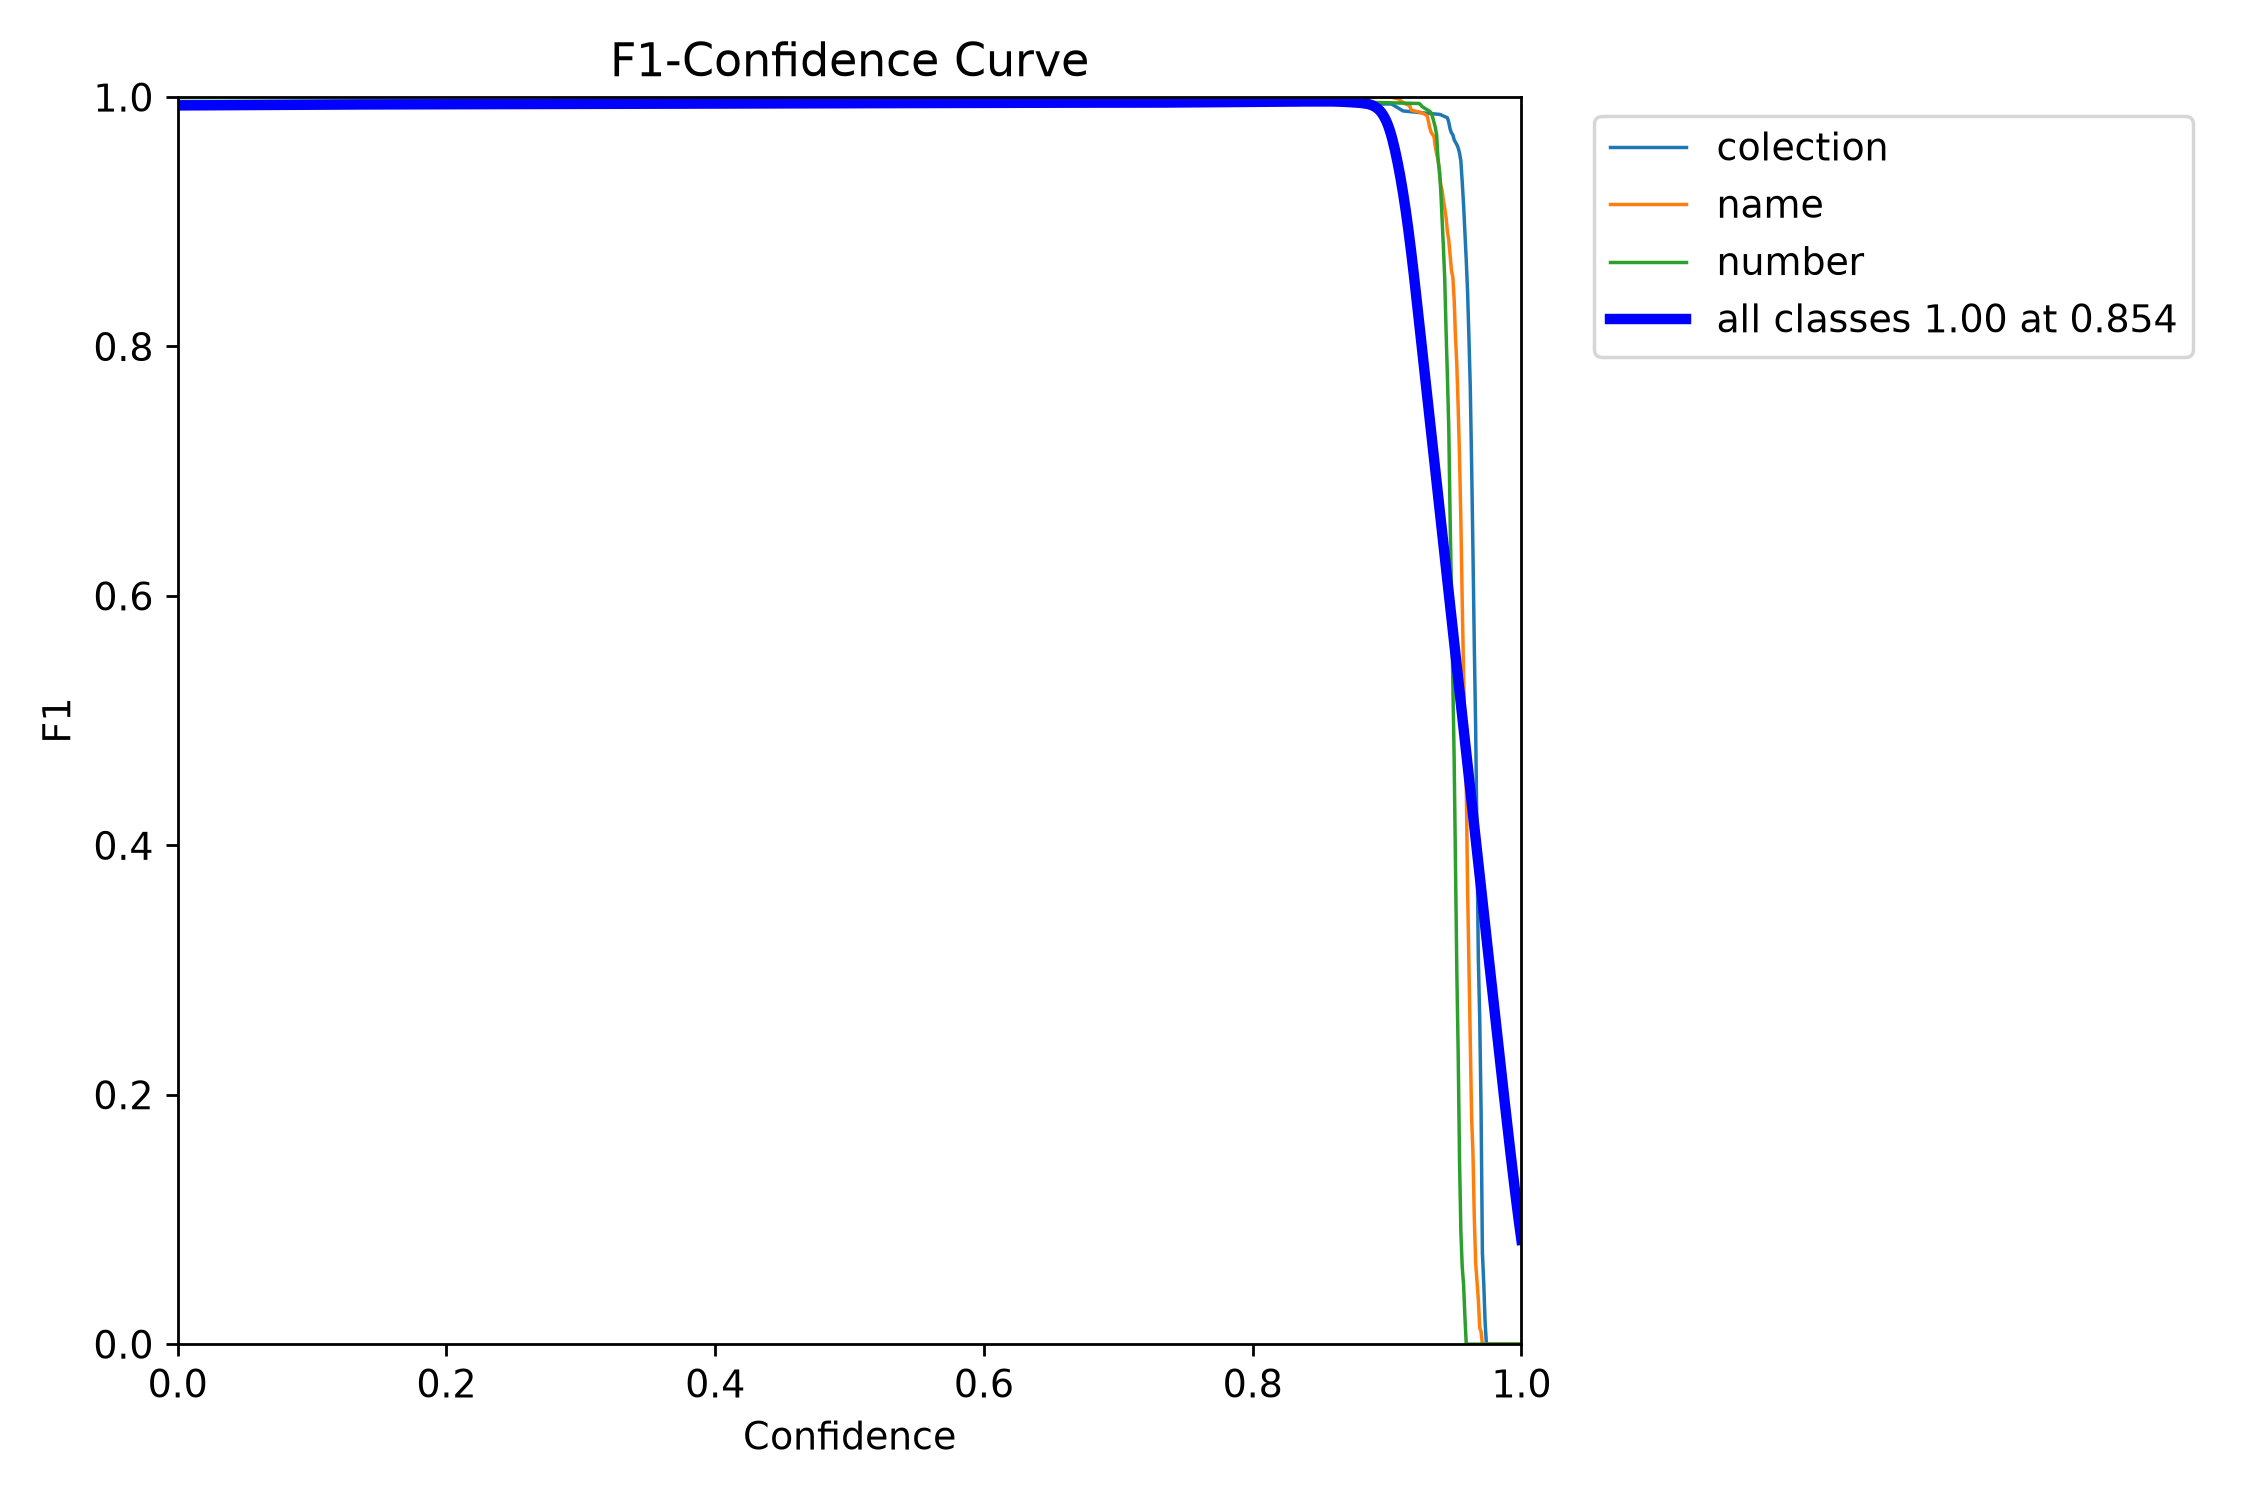

Curva Precision–Recall  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3\yolov8\report\BoxPR_curve.png


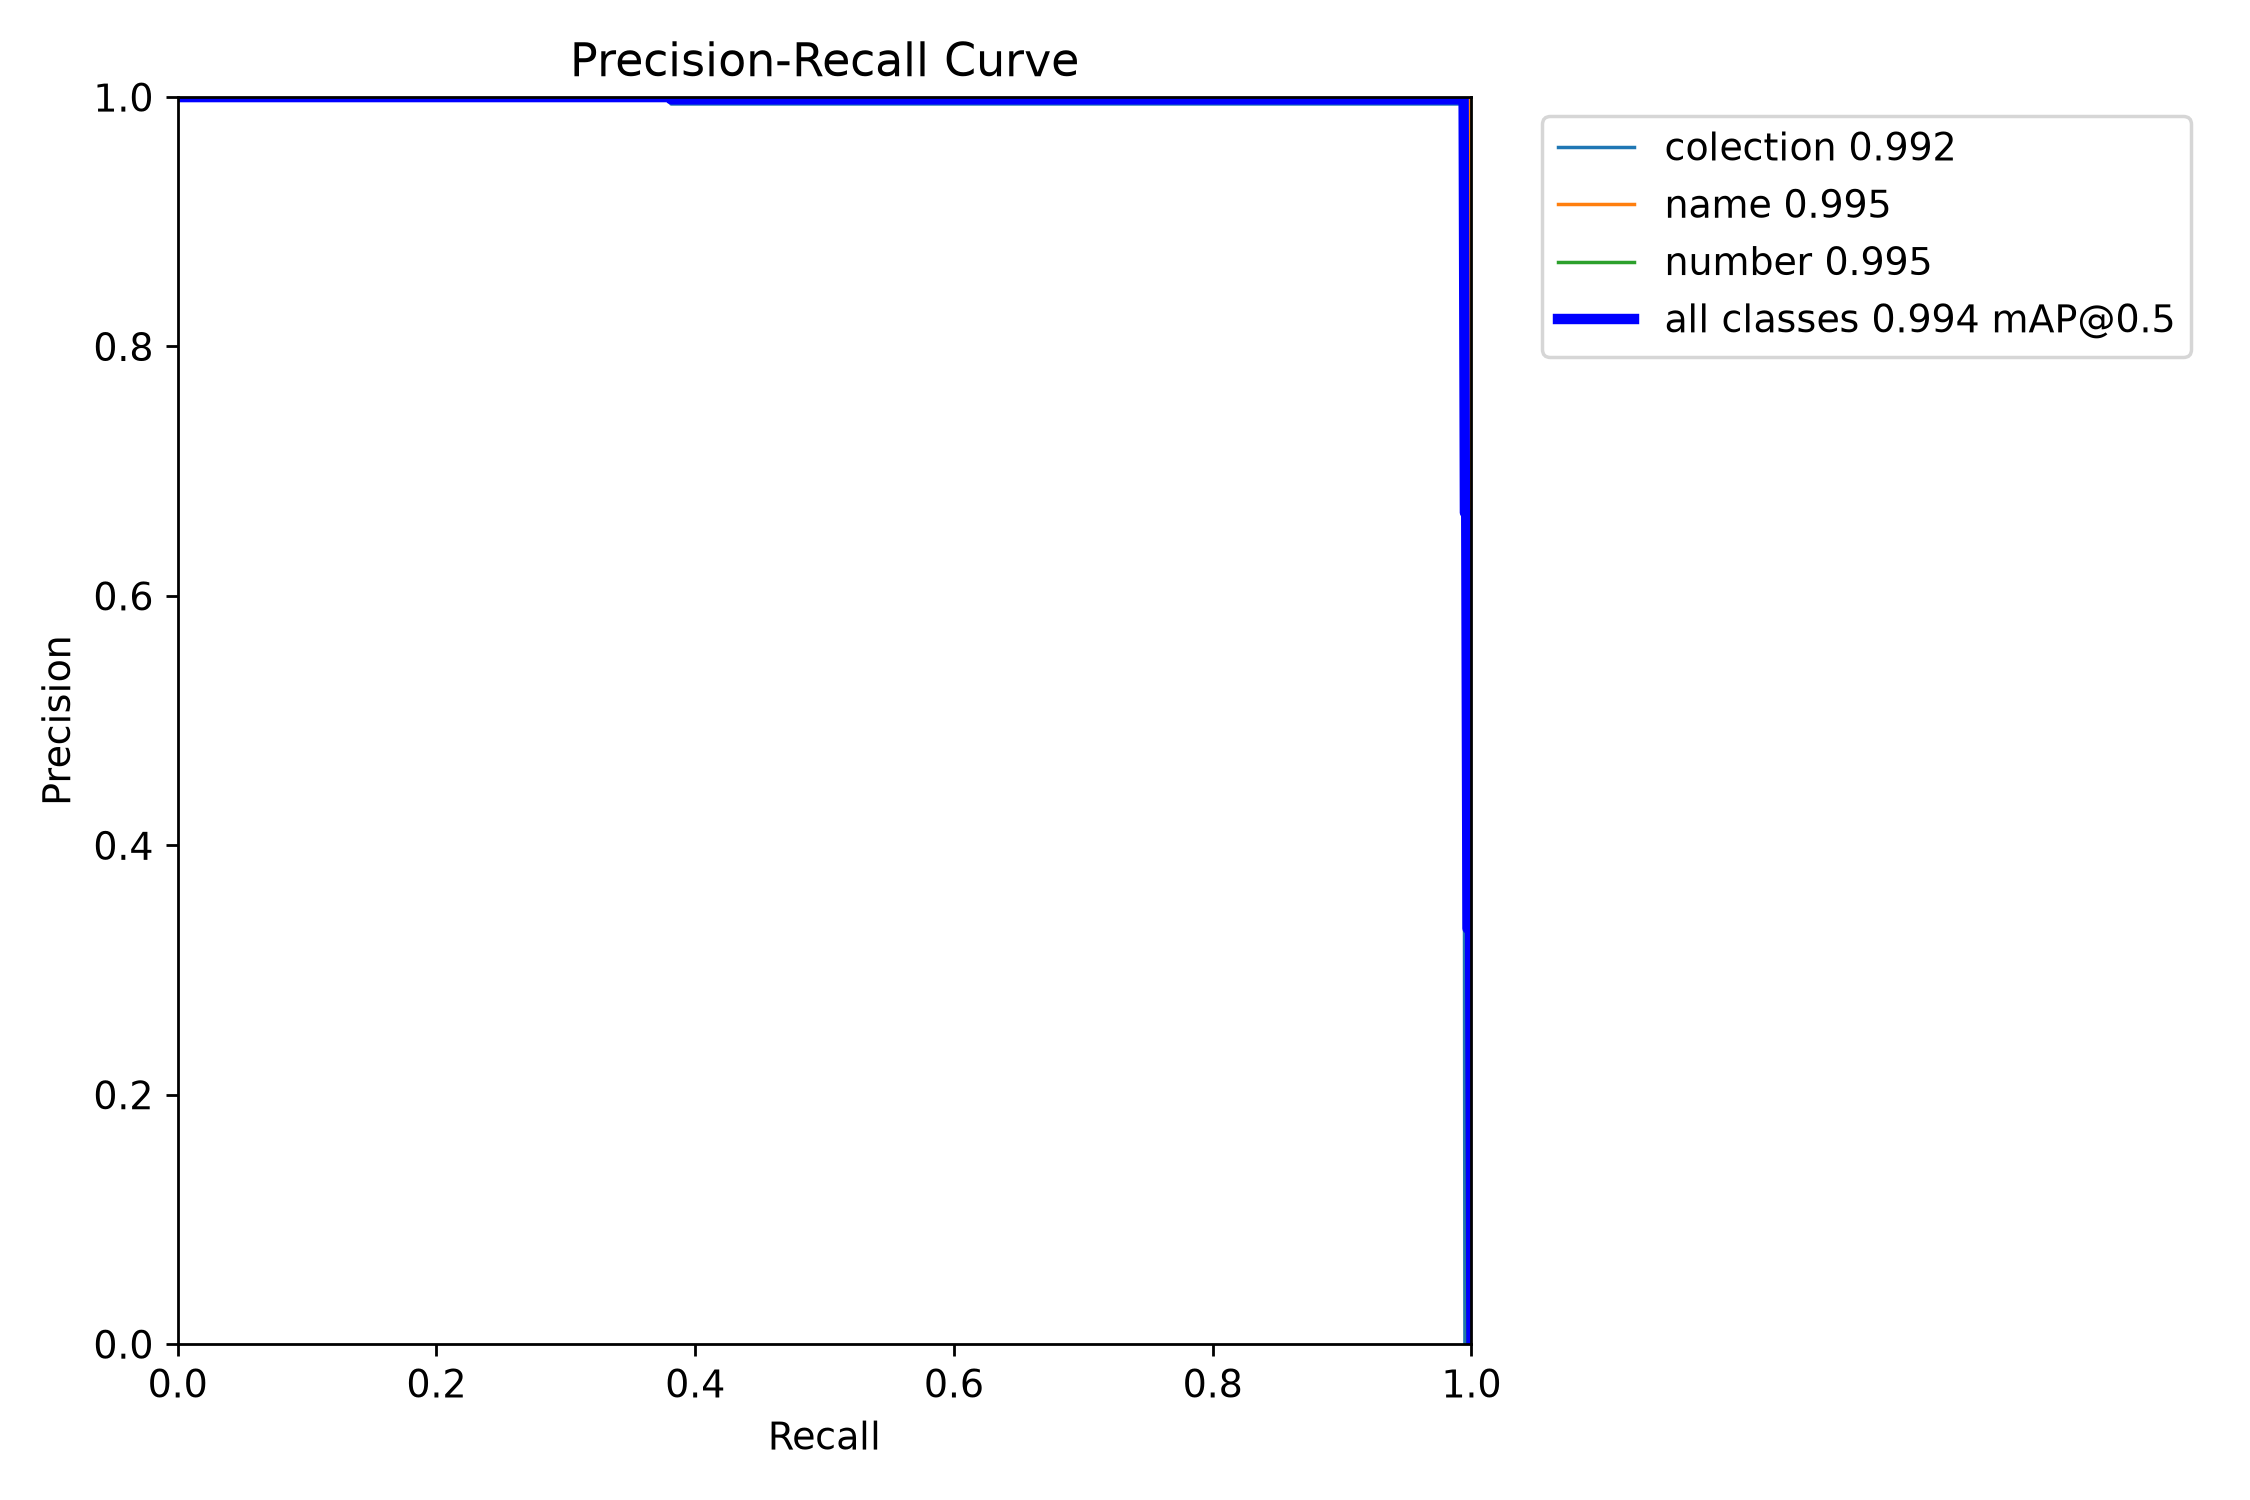

[ausente] results.png

Lotes de validação (labels vs predições)
val_batch0_labels.jpg


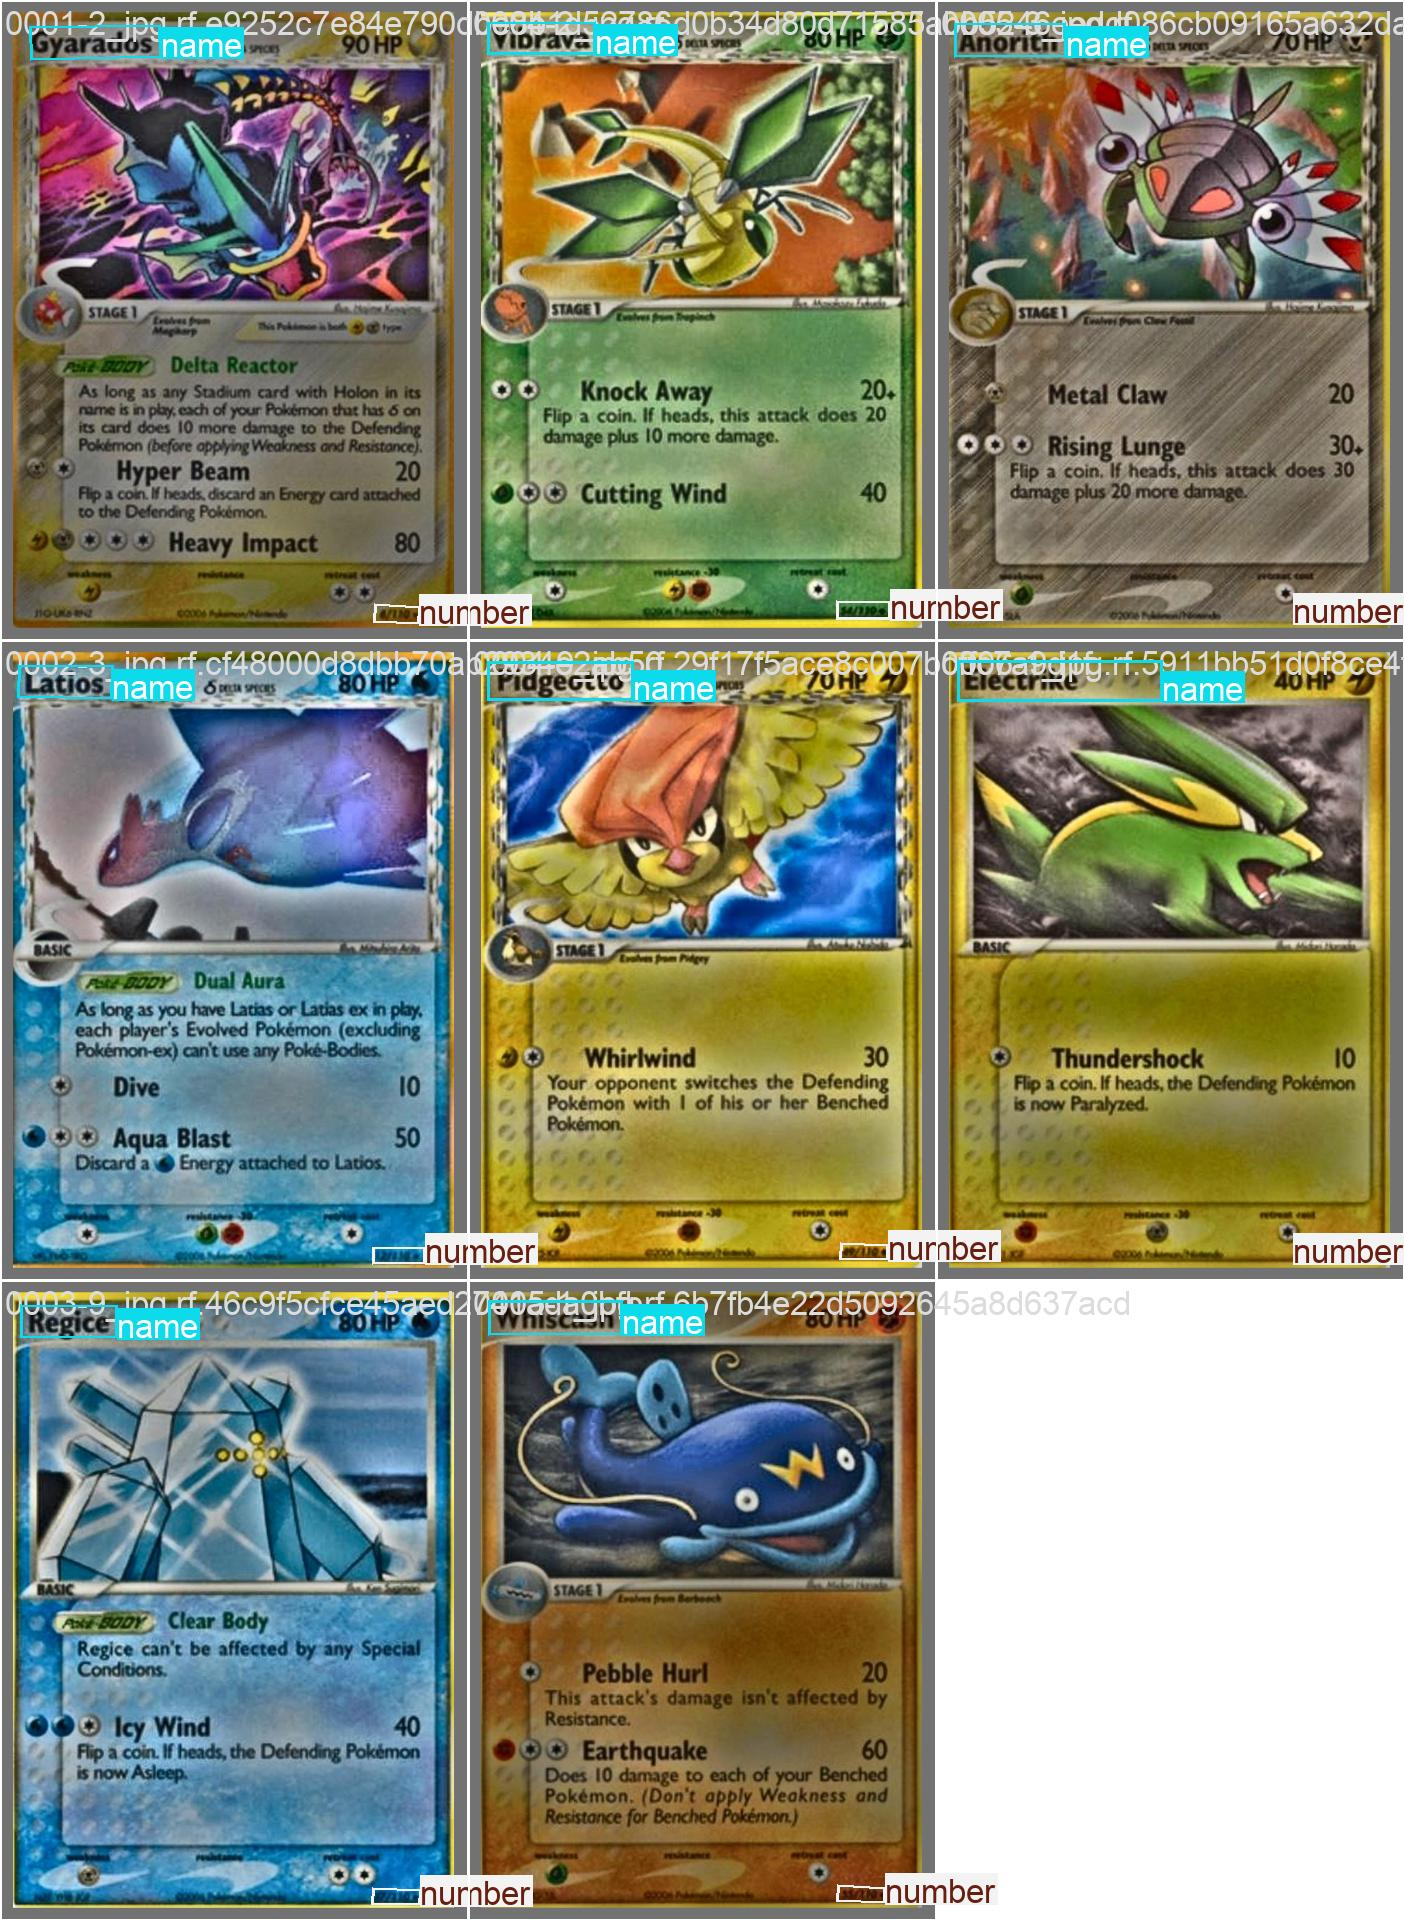

val_batch1_labels.jpg


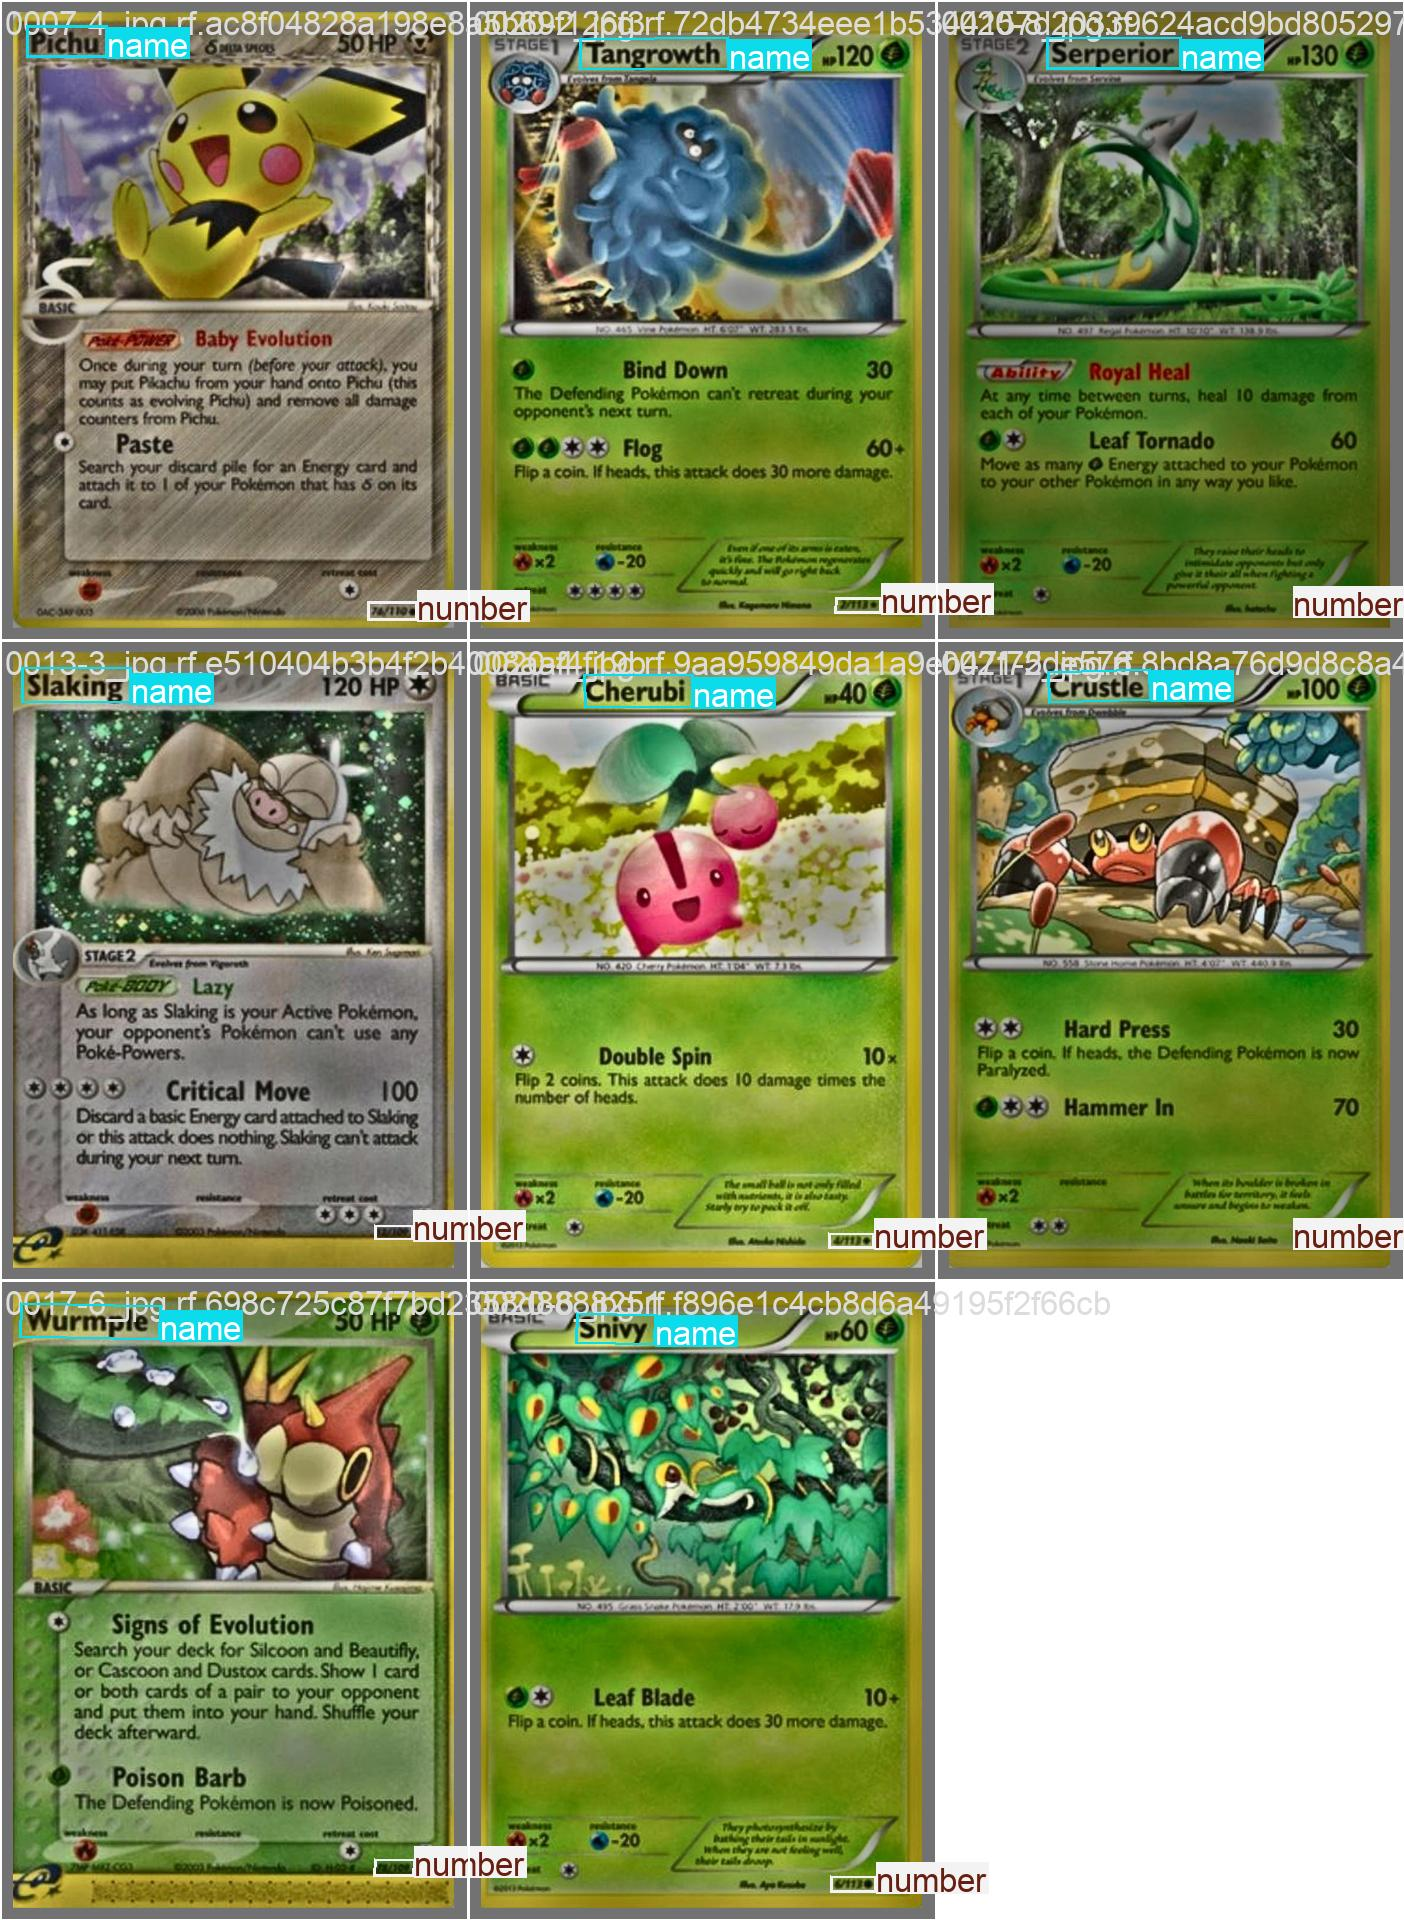

val_batch2_labels.jpg


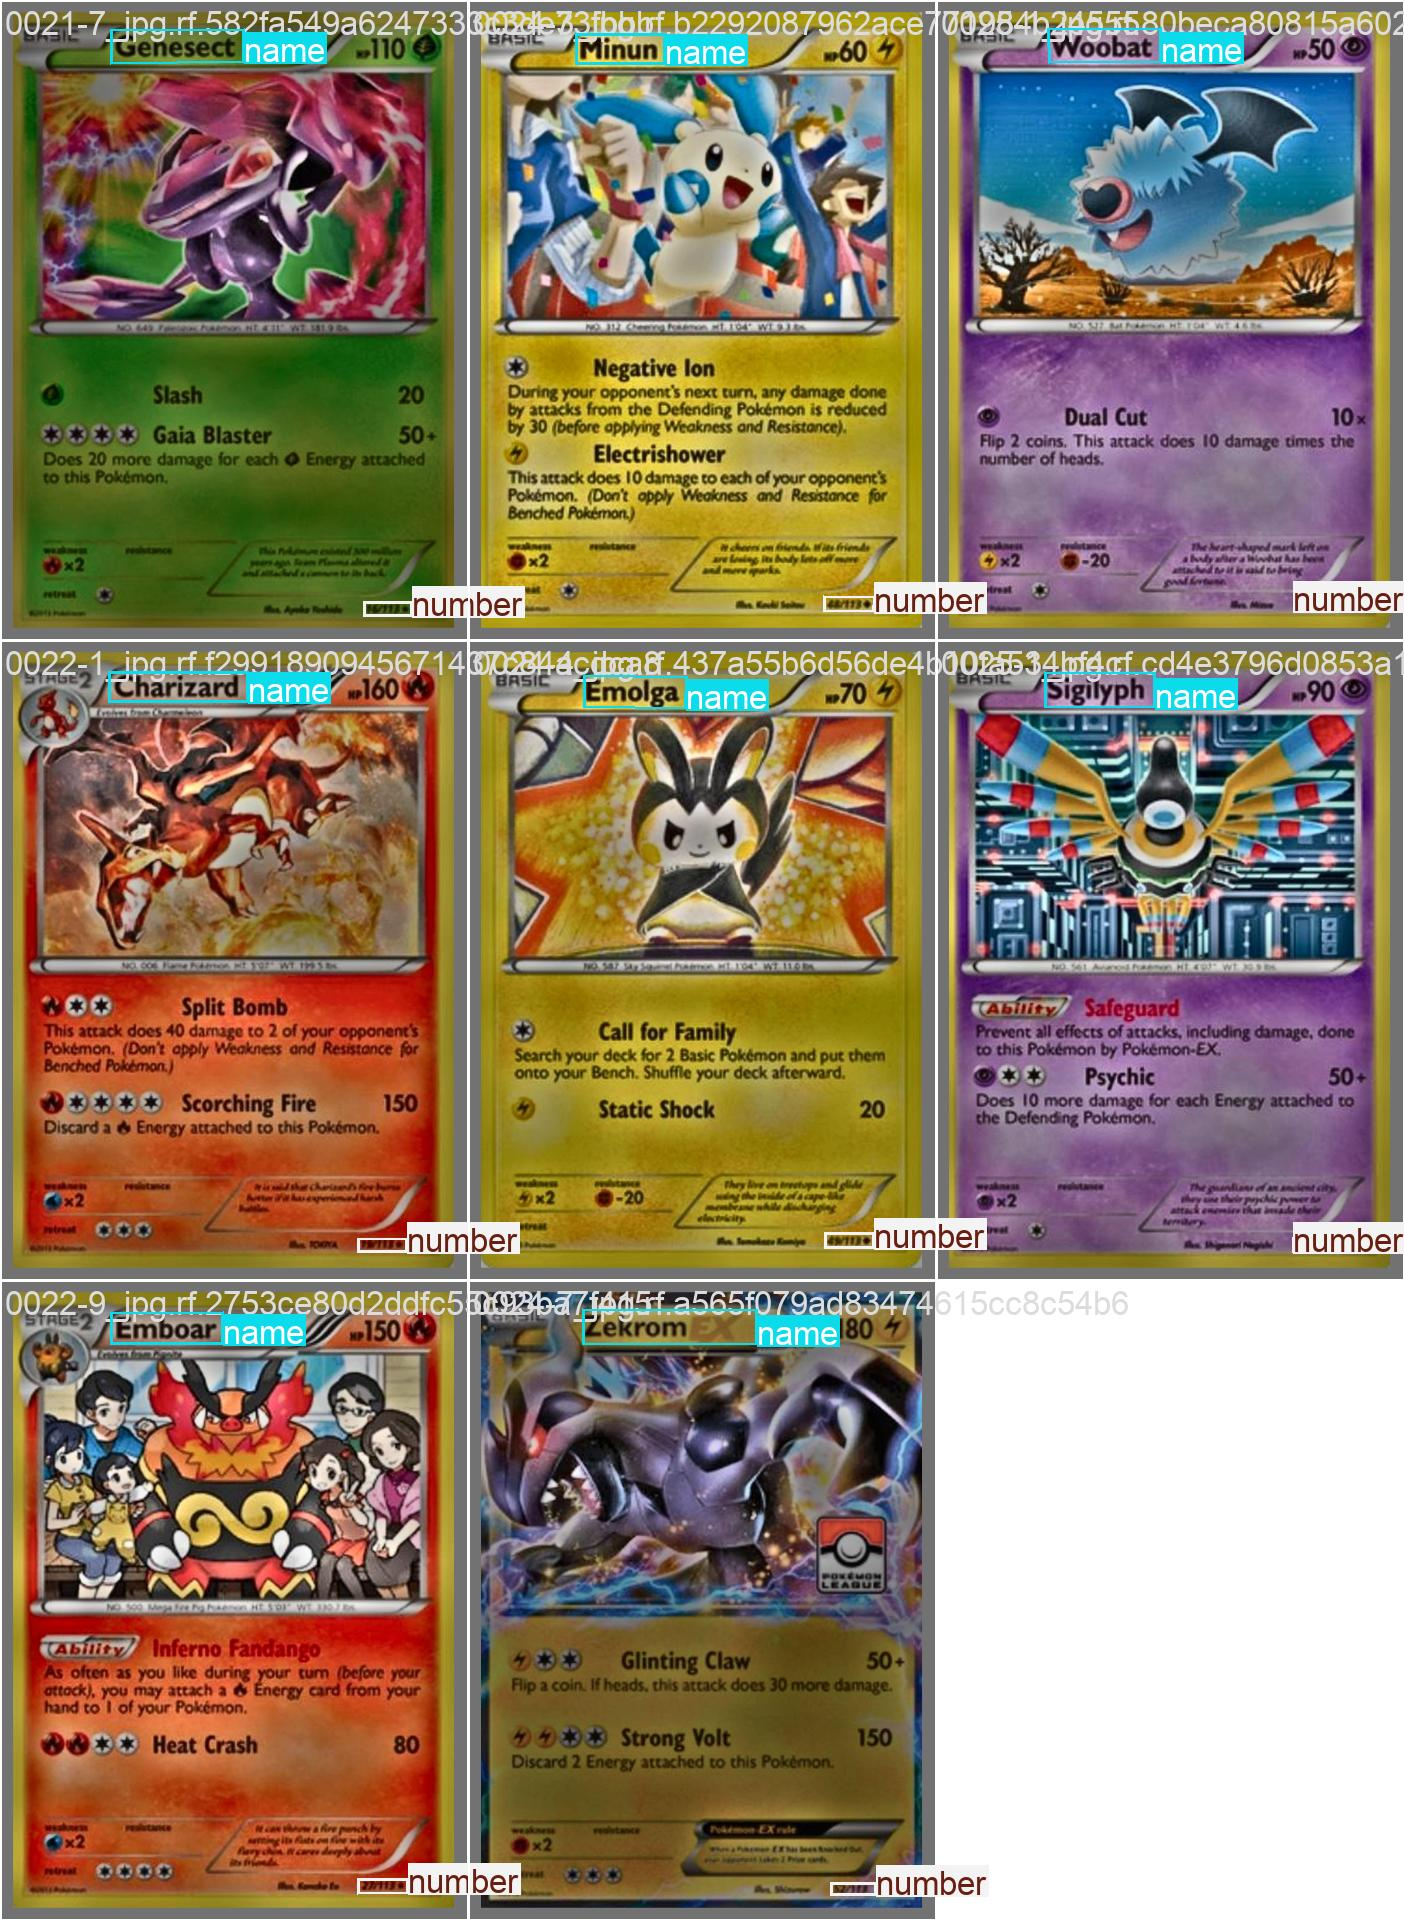

val_batch0_pred.jpg


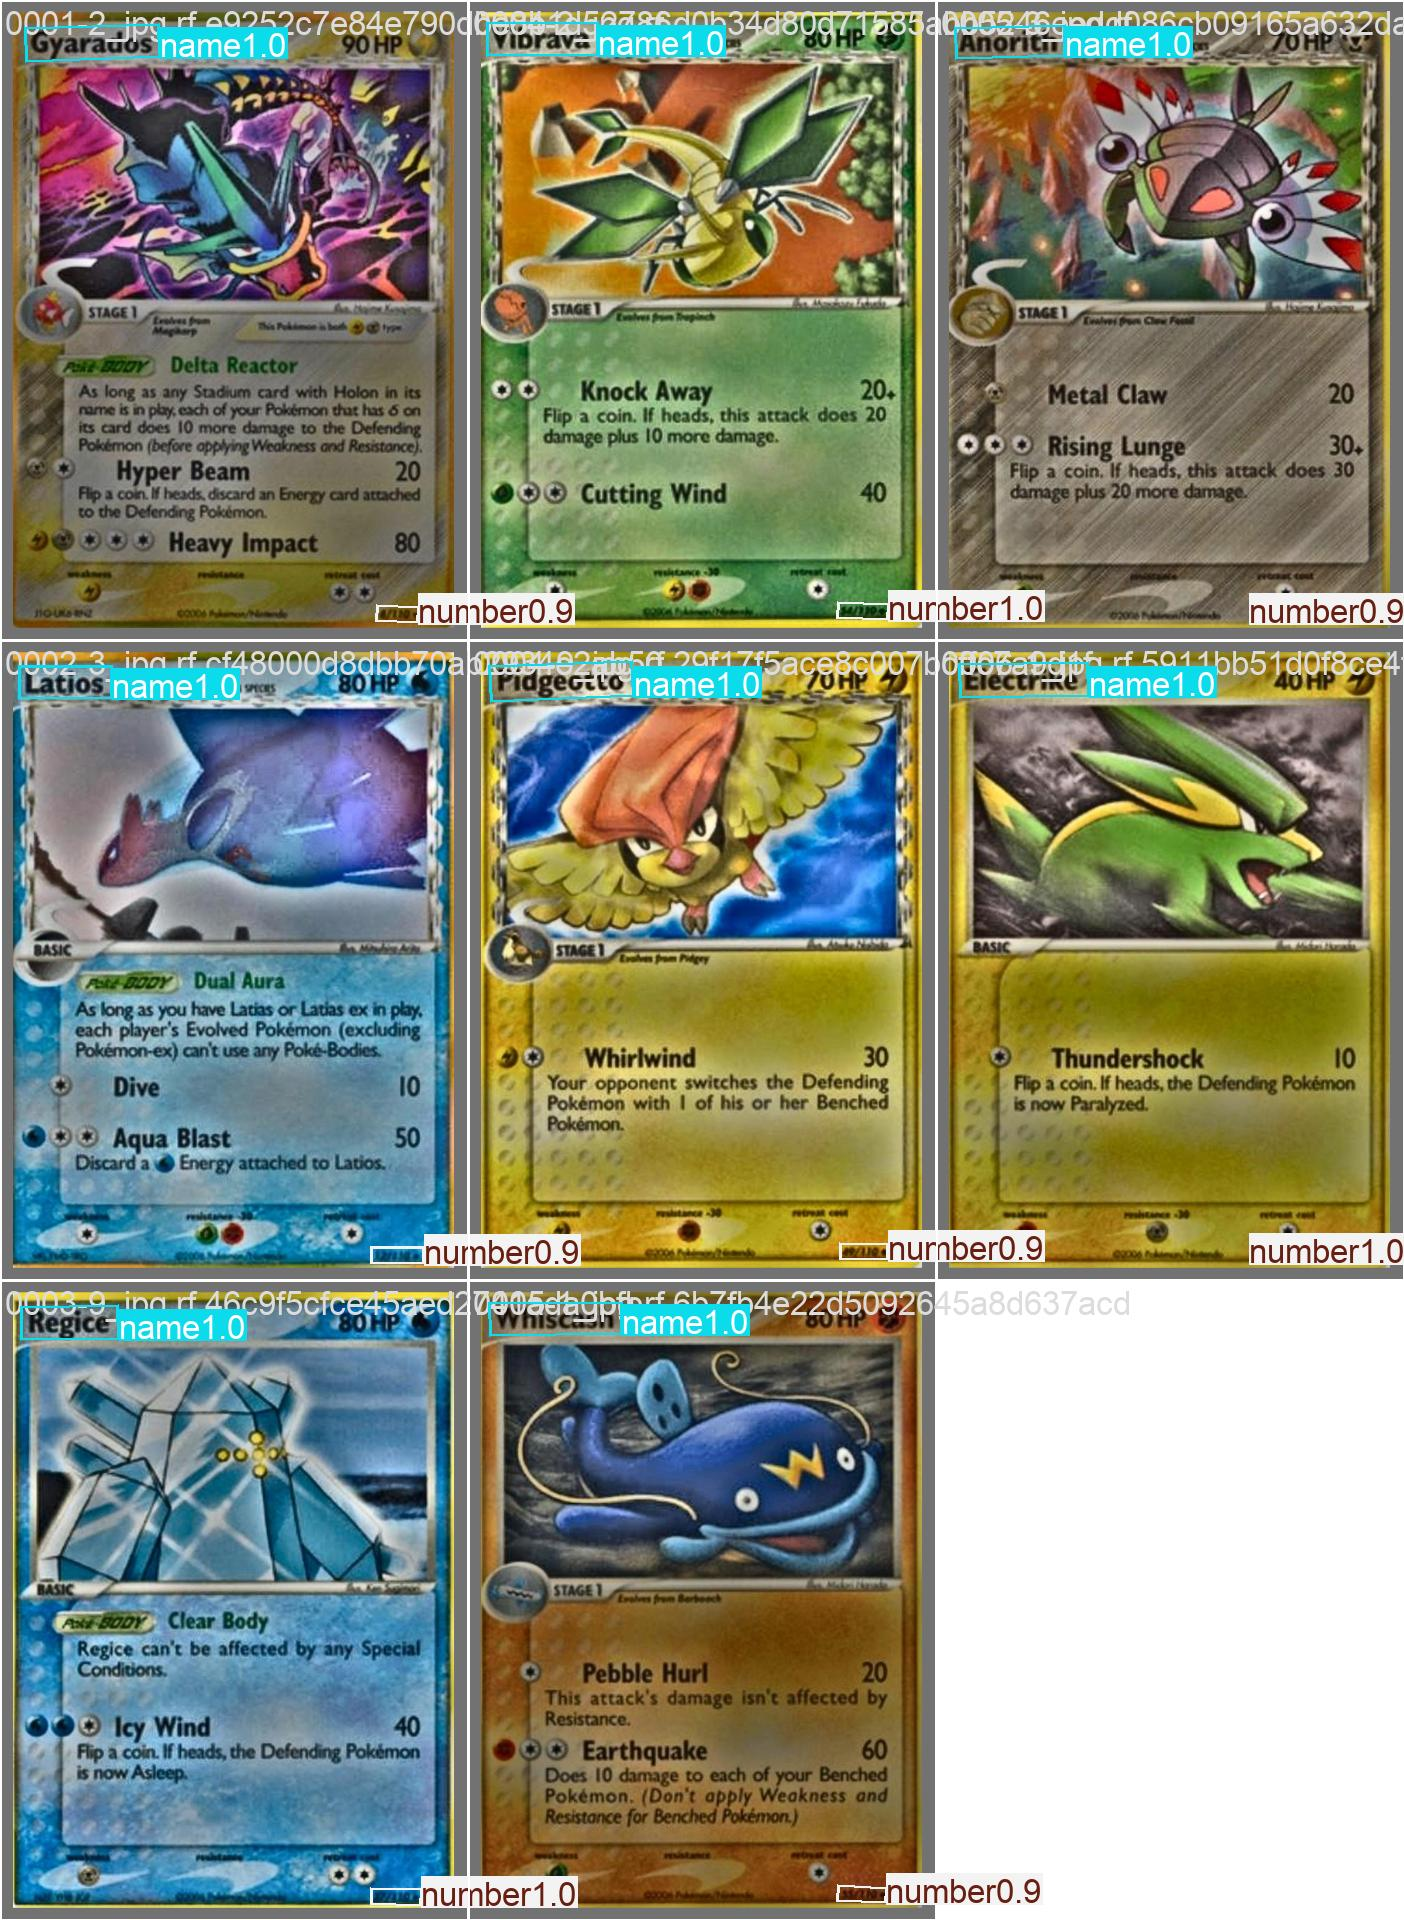

val_batch1_pred.jpg


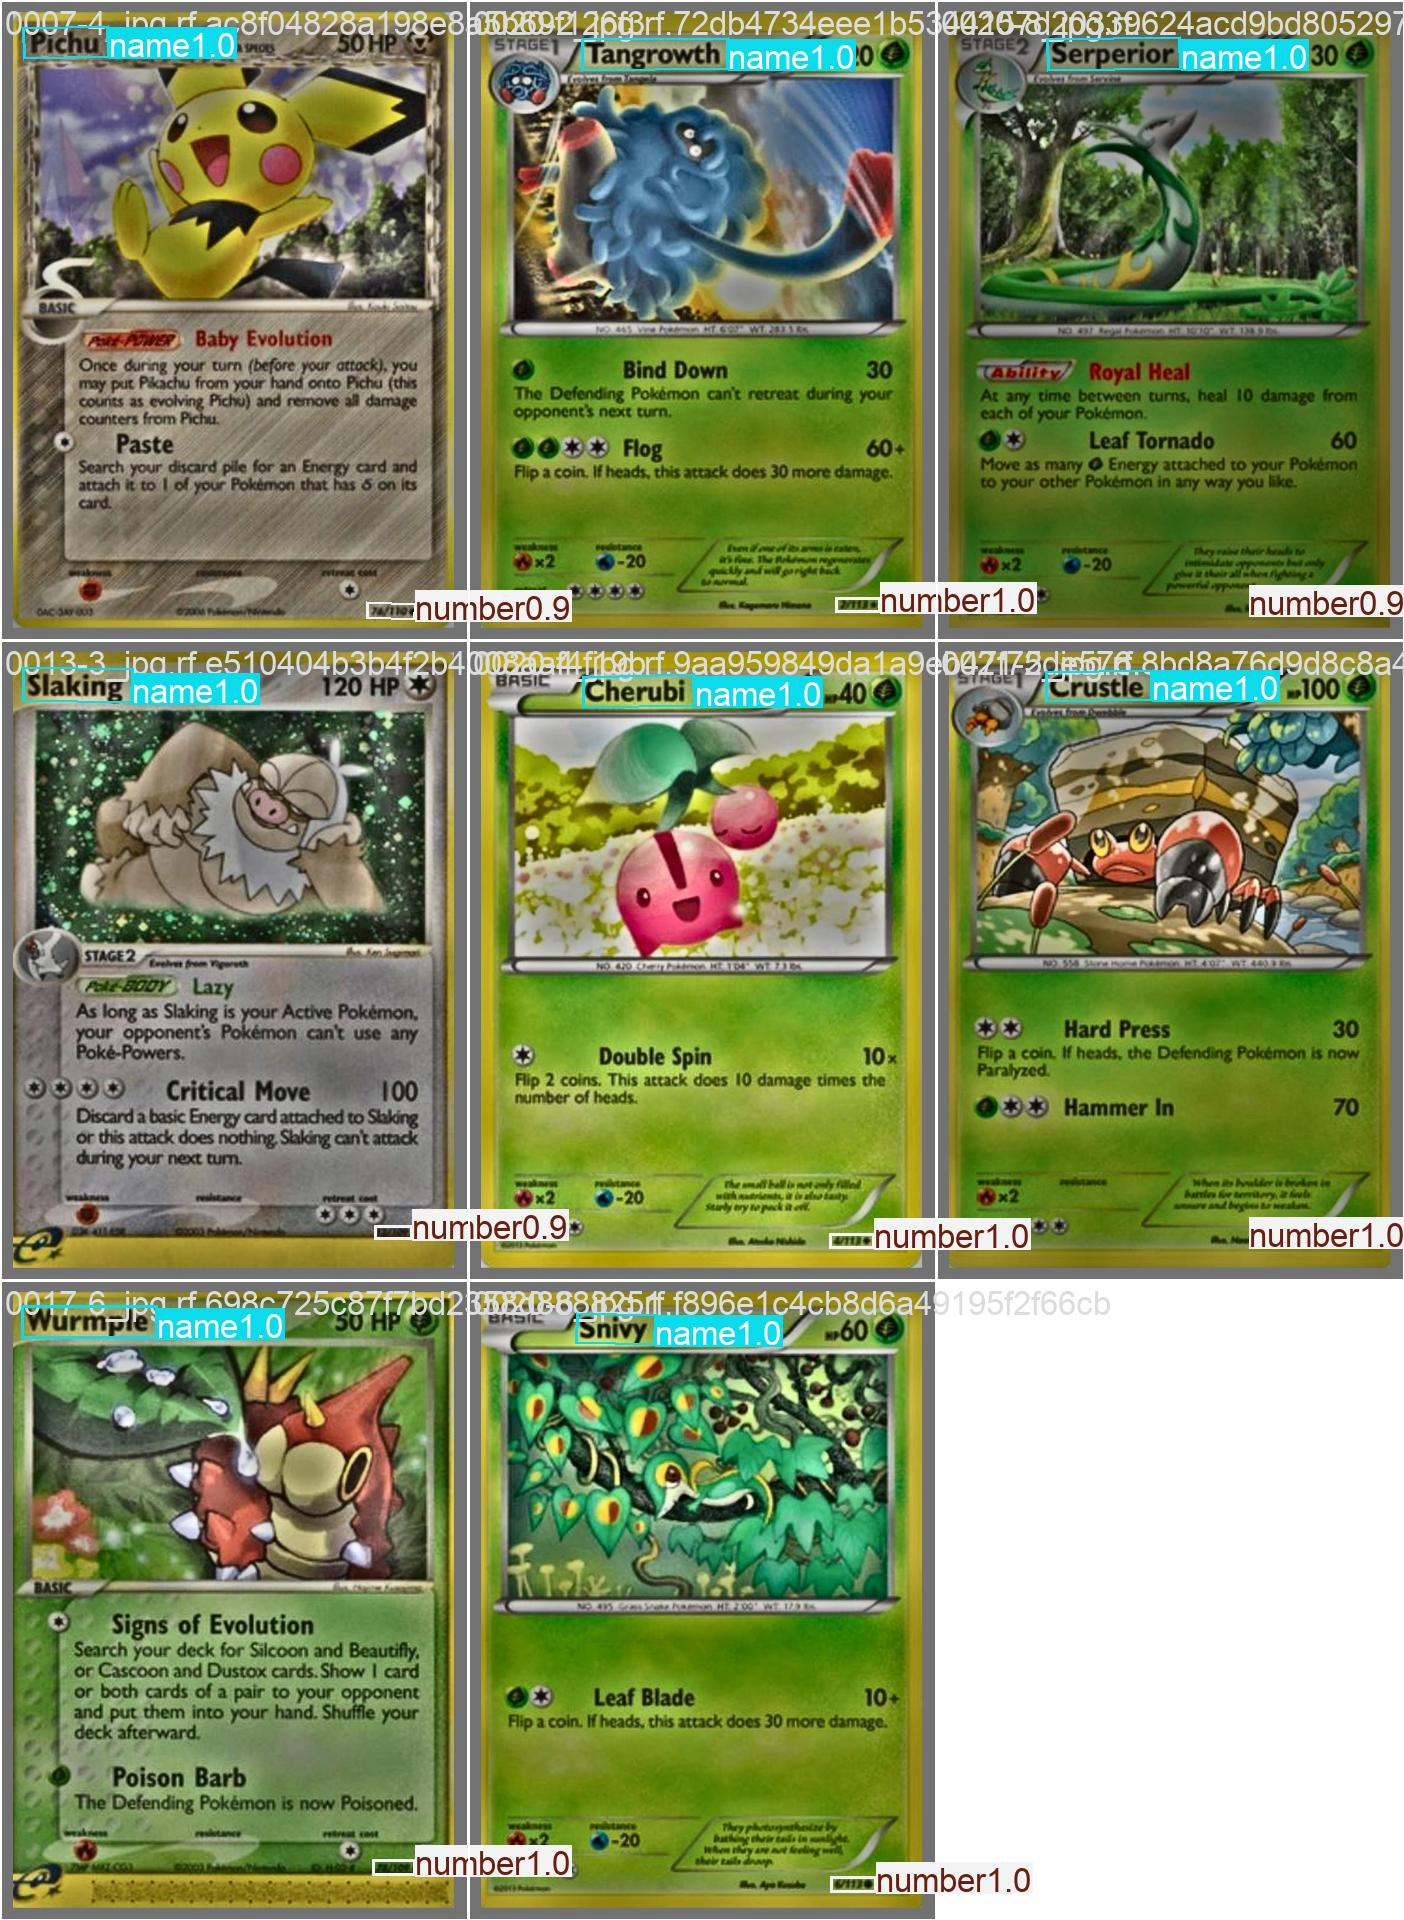

val_batch2_pred.jpg


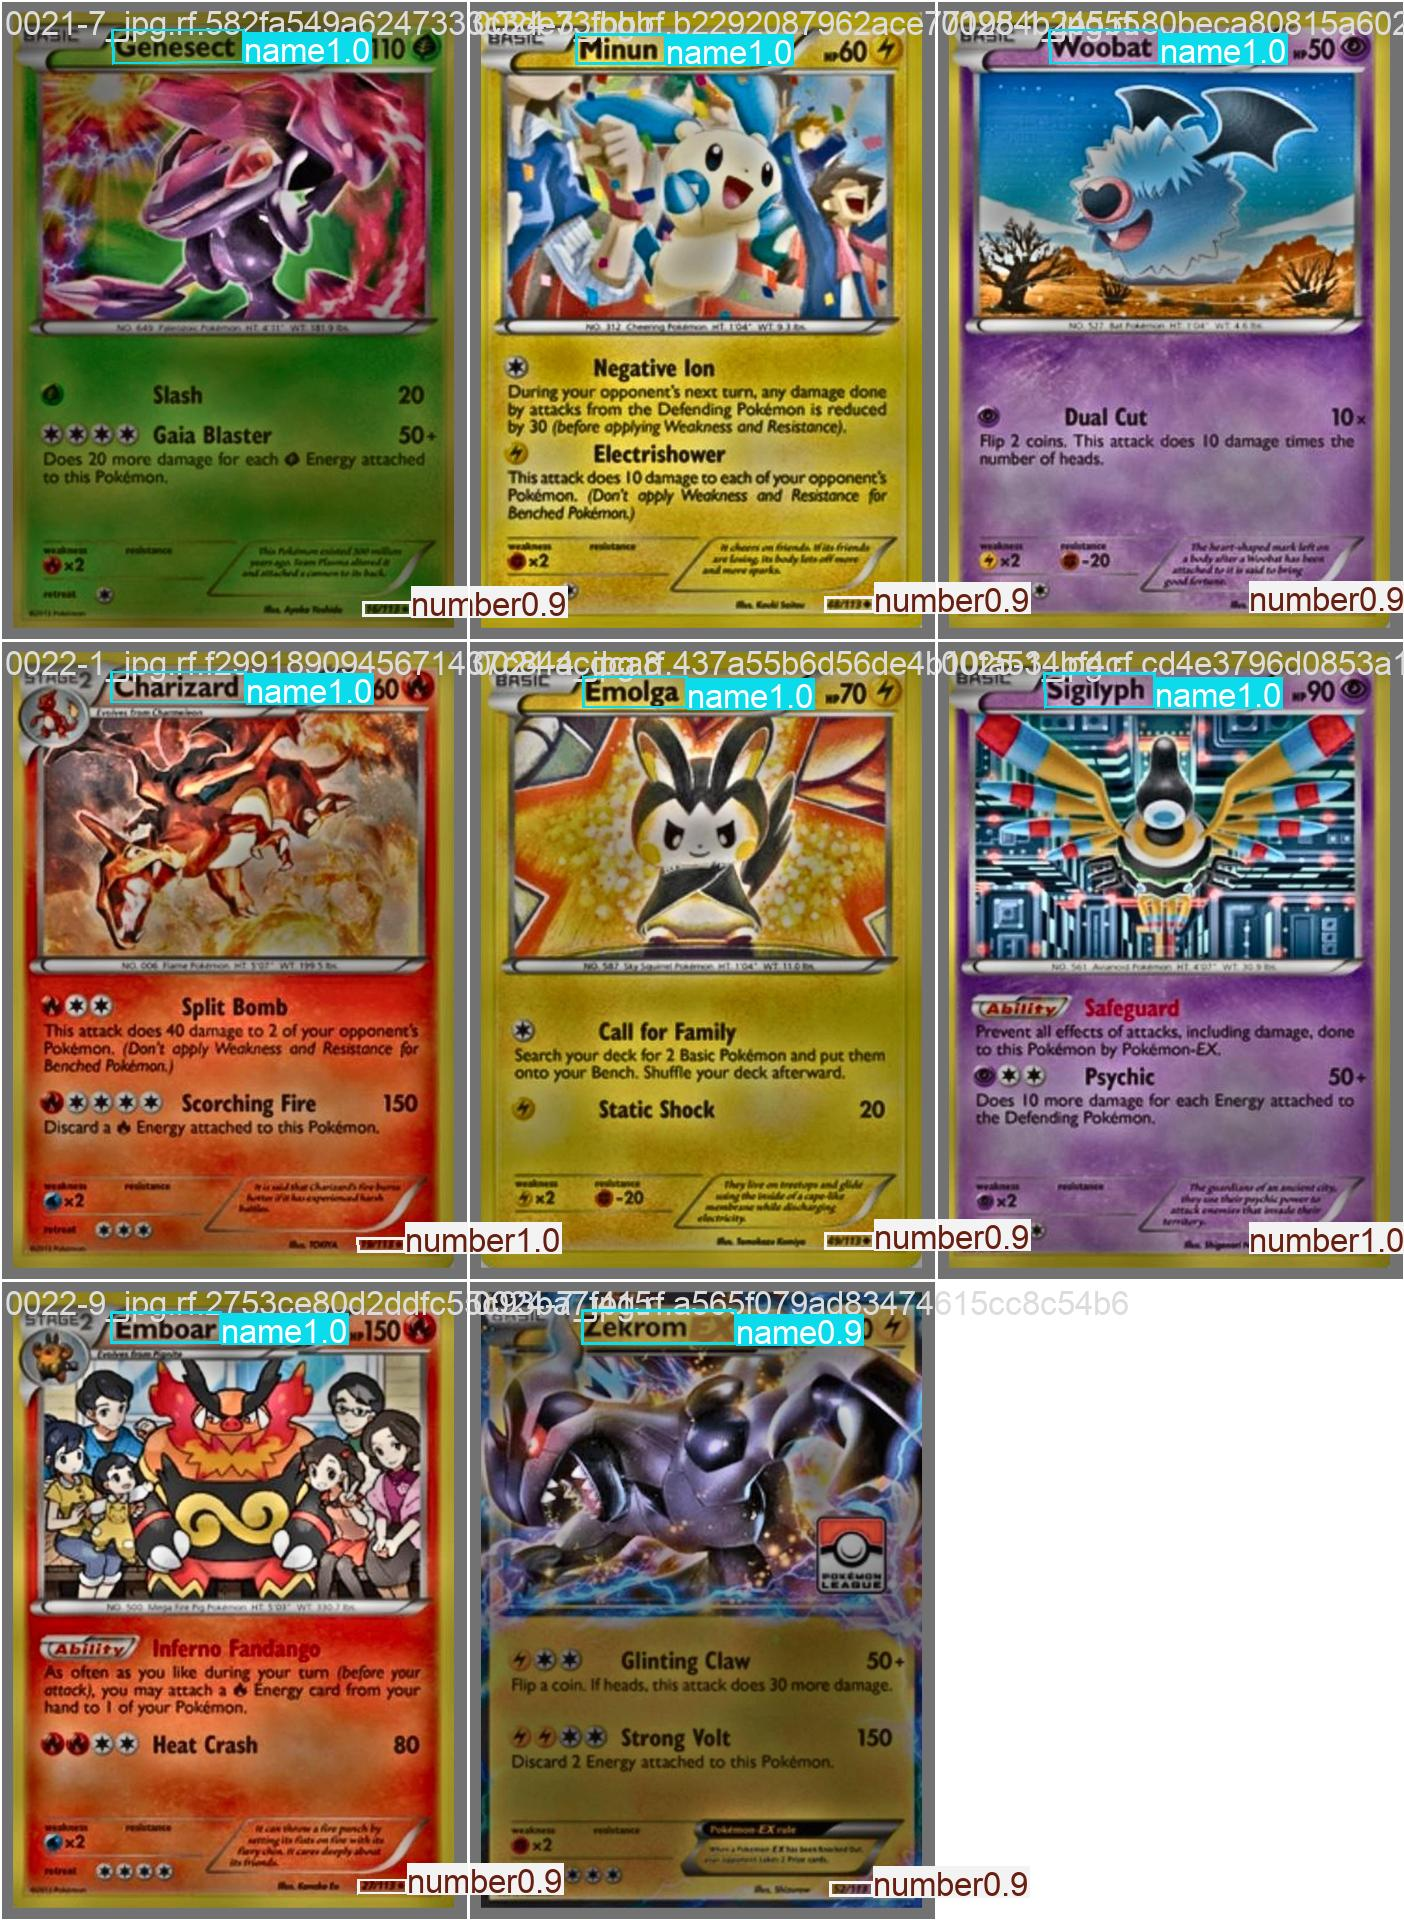

In [9]:
report_candidate(WINNER_ID, plots=True)


## 7. Predição no test (conf da aplicação)

Usa o **vencedor** da seção 5 (`ocr-roi-v3.pt`) com `conf=0.4`.


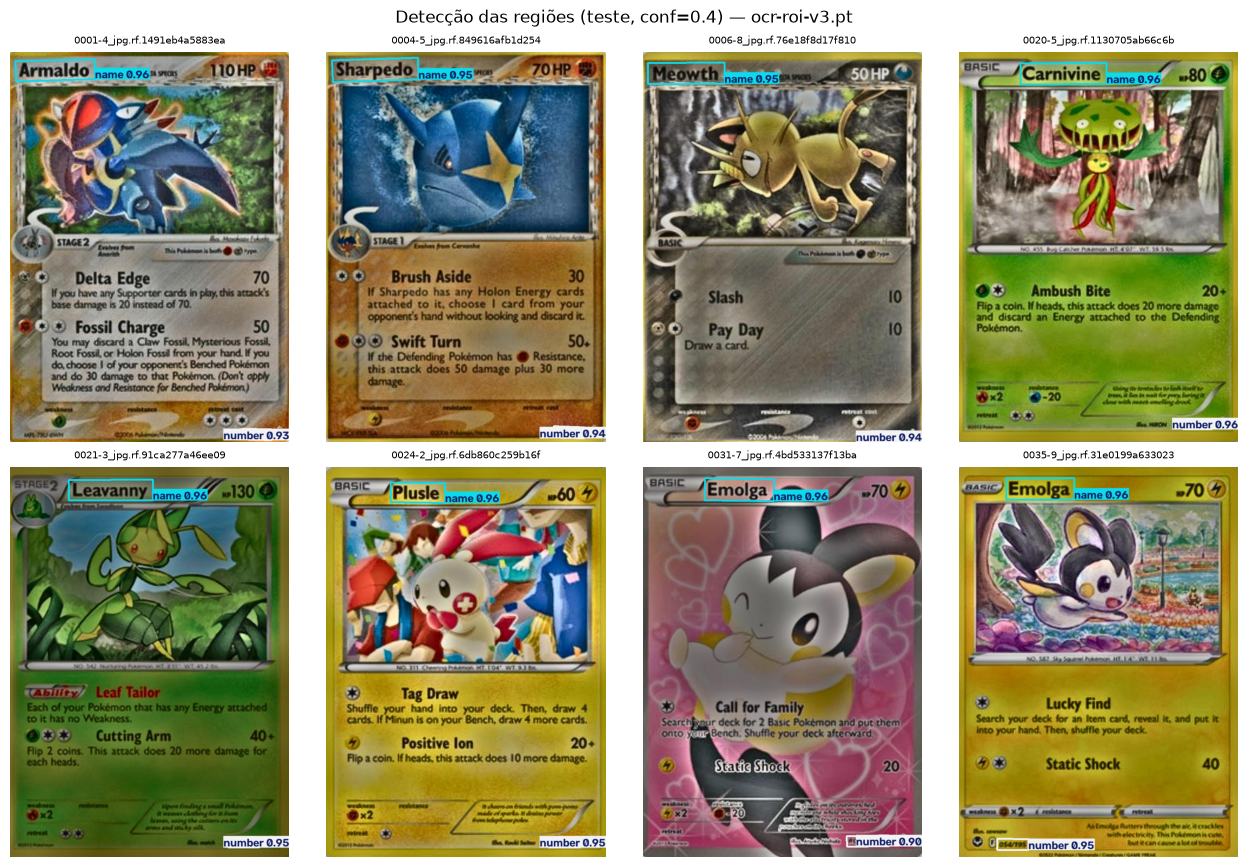

Pesos finais: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3\weights\ocr-roi-v3.pt


In [10]:
from ultralytics import YOLO

test_dir = DATASET_DIR / "test" / "images"
test_imgs = sorted(p for p in test_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
show = test_imgs[:MAX_SHOW]
if not show:
    raise FileNotFoundError(test_dir)

pt = WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt"
if not pt.is_file():
    pt = WEIGHTS_DIR / "best.pt"
roi_model = YOLO(str(pt))
preds = roi_model.predict(
    source=[str(p) for p in show],
    conf=CONF,
    imgsz=IMGSZ,
    device=DEVICE,
    verbose=False,
)

cols = min(4, len(show))
rows_n = int(np.ceil(len(show) / cols))
fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 4.4 * rows_n))
axes = np.atleast_1d(axes).ravel()
for ax, result in zip(axes, preds):
    vis = result.plot()
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(result.path).name[:28], fontsize=7)
    ax.axis("off")
for ax in axes[len(show):]:
    ax.axis("off")
fig.suptitle(f"Detecção das regiões (teste, conf={CONF}) — {pt.name}")
plt.tight_layout()
plt.show()
print(f"Pesos finais: {pt}")


## Uso rápido

```python
from ultralytics import YOLO

model = YOLO("src/roi/runs/ocr-roi-v3/weights/ocr-roi-v3.pt")
results = model.predict("data/roi/test/images", conf=0.4, imgsz=800)
```

Ranking: `src/roi/runs/ocr-roi-v3/ranking.csv`. Relatórios: `src/roi/runs/ocr-roi-v3/<id>/report/`.

A pipeline ainda carrega **ocr-roi-v2** até você copiar o v3.
